# NB06 — Discovery Layer
**Signal/Pulse · Unsupervised NLP + Search Discovery**

Two discovery engines:
- **Review text** (Sections 1–3, 5): what consumers *say* in @cosme reviews
- **Search behaviour** (Section 4): what consumers *search for* on Google

Convergence between the two = double-confirmed signal.
Terms in search but absent from reviews = leading indicator.

| Section | Technique | Signal source |
|---|---|---|
| 1 | TF-IDF delta | Review text vocabulary shift |
| 2 | Cosine similarity | Category vocabulary convergence |
| 3 | LDA | Latent review topics |
| 4 | Block C treemap | Rising Google search queries |
| 5 | UMAP + HDBSCAN | Corpus spatial structure |
| 6 | Synthesis | What did we find? |

**Public notebook — brand-agnostic.**
Company lens analysis in NB05a/b/c (private, gitignored).

**Jaccard note:** Ingredient overlap deferred — SudachiPy Mode C splits
compounds (ヒアルロン酸 → ヒアルロン + 酸). Future: Mode B or custom dictionary.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import sqlite3
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import LatentDirichletAllocation

import hdbscan
import umap

from src.utils import load_env, DATA_RAW
from src.schema import get_connection, DB_PATH
from src.config import PROJECT

load_env()

# ── Chart helpers ──────────────────────────────────────────────────────
C_SKIN    = '#4A90B8'   # Derma Clarity — calm blue
C_COSM    = '#C4627A'   # Derma Clarity — dusty rose
C_INGR    = '#5B8C6E'   # sage green — ingredients
C_KOREAN  = '#D4785C'   # terracotta — Korean brands
C_GOLD    = '#B8965A'   # annotation gold
C_NEUTRAL = '#78909C'

plt.rcParams.update({
    'font.family': 'Yu Gothic',
    'font.size': 10,
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
})

def fig_ax(w=10, h=6):
    fig, ax = plt.subplots(figsize=(w, h), facecolor='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return fig, ax

def tight(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')

# ── Verify environment ─────────────────────────────────────────────────
import matplotlib.font_manager as fm
yu = [f for f in fm.findSystemFonts() if 'yugoth' in f.lower()]
print(f"Font: Yu Gothic {'✓' if yu else '✗ — install Yu Gothic'}")
print("Environment ready ✓")

# SudachiPy check
from sudachipy import Dictionary
tokenizer = Dictionary().create()
test = tokenizer.tokenize("化粧水で美容液をスキンケアする")
print(f"SudachiPy test: '{' '.join(m.dictionary_form() for m in test)}' ✓")
print()
print(f"  hdbscan ✓")
print(f"  umap ✓")

20:35:44  INFO      .env loaded from C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\6. Beauty_ConsumerPulse\.env


Font: Yu Gothic ✓
Environment ready ✓
SudachiPy test: '化粧水 で 美容 液 を スキンケア する' ✓

  hdbscan ✓
  umap ✓


In [2]:
# ── Load review corpus ────────────────────────────────────────────────────
conn = get_connection()

sql = """
    SELECT r.review_id, r.review_text, r.review_year, r.rating,
           r.char_count, r.source_id, r.category_id,
           c.tier, c.normalized_name AS category_name,
           s.source_name
    FROM reviews r
    JOIN categories c USING (category_id)
    JOIN sources s    USING (source_id)
    WHERE r.review_text IS NOT NULL
      AND LENGTH(r.review_text) > 20
      AND r.review_year BETWEEN 2019 AND 2026  -- latest year partial (mid-year)
"""
df_corpus = pd.read_sql(sql, conn)
print(f"Corpus: {len(df_corpus):,} reviews")
print(f"Date range: {df_corpus.review_year.min()} – {df_corpus.review_year.max()} (latest year partial)")

# Broad tier mapping
SKIN_TIERS = {
    'skincare', 'mass_skincare', 'sensitive_skincare',
    'prestige_skincare', 'sun_protection', 'dermo_skincare'
}
COSM_TIERS = {
    'cosmetics', 'mass_cosmetics', 'prestige_cosmetics', 'base_makeup'
}
tier_counts = df_corpus['tier'].apply(
    lambda t: 'skincare' if t in SKIN_TIERS else 'cosmetics' if t in COSM_TIERS else 'other'
).value_counts()
print(f"Tiers: {dict(tier_counts)}")

# ── Tokenise with SudachiPy Mode C ───────────────────────────────────
from sudachipy import Dictionary, SplitMode
tok = Dictionary().create()

CONTENT_POS = {'名詞', '動詞', '形容詞', '副詞'}

def tokenise(text):
    if not text or not isinstance(text, str):
        return ''
    morphemes = tok.tokenize(text, SplitMode.C)
    tokens = []
    for m in morphemes:
        pos = m.part_of_speech()[0]
        if pos in CONTENT_POS:
            form = m.dictionary_form()
            if len(form) > 1:  # skip single-char particles
                tokens.append(form)
    return ' '.join(tokens)

print("\nTokenising... (2-3 min)")
df_corpus['tokens'] = df_corpus['review_text'].apply(tokenise)
df_corpus = df_corpus[df_corpus['tokens'].str.len() > 0].copy()
print(f"After tokenisation: {len(df_corpus):,} reviews retained")

Corpus: 39,978 reviews
Date range: 2019 – 2026 (latest year partial)
Tiers: {'skincare': np.int64(26605), 'cosmetics': np.int64(13373)}

Tokenising... (2-3 min)
After tokenisation: 39,978 reviews retained


## 1. Emerging Terms — TF-IDF Delta 2019→2026

Split corpus into pre-COVID (≤2020) and recent (≥2023).
Fit TF-IDF on combined vocabulary, compute per-term weight shift.

**Caveat:** Pre-COVID corpus is ~565 reviews vs ~12,500 recent.
Direction is confirmed by Google Trends (NB05). Treat extreme
percentage changes with caution — small-sample artefact.

In [3]:
# ── Japanese stopwords (shared across all NLP sections) ────────────────
JP_STOPWORDS = [
    # Function verbs SudachiPy retains
    'する', 'いる', 'ある', 'ない', 'なる', 'くれる', 'みる',
    'おく', 'くる', 'もらう', 'やる', 'いく',
    'いう', 'つく', 'つける', 'しまう', 'すぎる', '塗る',
    'できる', '見る', '入る', 'ござる',
    # Compound function verb bigrams
    'する いる', 'する くれる', 'なる いる', 'する する',
    'する ない', 'いる ない', 'ある ない',
    'しっとり する', 'リピ する', 'コスメ プレゼント',
    '乾燥 する', '使う みる', '見る みる', 'できる いる',
    # Generic sentiment / filler
    'いい', 'よい', 'もの', 'こと', 'ため', 'よう', 'ので',
    'とても', 'すごく', 'かなり', 'ちょっと', 'なんか',
    # Generic quantity / degree adjectives
    '多い', '少ない', '大きい', '小さい', '長い', '短い',
    'すごい',
    # Common adverbs — pure filler
    'とく', 'ぜひ', 'ほど', 'だけ', 'まだ', 'また', 'もう',
    'いつも', 'ずっと', 'すぐ', '今まで',
    # Review structure noise
    '思う', '感じ', '感ずる', '良い', '本当', '購入', '使用',
    '商品', '自分', '今回', 'ちゃん', 'さん', 'くん',
    'こちら', 'そちら', 'あちら', 'ところ', 'ほう',
    'なんと', 'やっぱ', 'やはり',
    # Politeness verbs
    '頂く', 'いただく',
    # Platform/giveaway noise
    '当選', 'モニター',
    # Temporal filler
    '最近', '久しぶり', '今日', '毎日', '毎朝', '毎晩',
    # Review filler bigrams
    '使う いる', '本当 いい', '購入 する', '使用 する',
    'プレゼント する', '感じ する', '思う いる',
    'こと いる', 'もの いる', 'ため いる',
    'とても いい', 'すごく いい', 'とても 良い',
]
SW_SET = set(JP_STOPWORDS)

# ── Split corpus ──────────────────────────────────────────────────────
pre  = df_corpus[df_corpus.review_year <= 2020]['tokens'].tolist()
post = df_corpus[df_corpus.review_year >= 2023]['tokens'].tolist()

print(f"Pre-COVID corpus  (2019–2020): {len(pre):,} reviews")
print(f"Recent corpus     (2023–2026): {len(post):,} reviews")

# ── Fit TF-IDF on combined vocabulary ─────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000,
    min_df=5,
    sublinear_tf=True,
)
tfidf.fit(pre + post)
vocab = tfidf.get_feature_names_out()

pre_matrix  = tfidf.transform(pre)
post_matrix = tfidf.transform(post)

pre_mean  = np.asarray(pre_matrix.mean(axis=0)).flatten()
post_mean = np.asarray(post_matrix.mean(axis=0)).flatten()

df_delta = pd.DataFrame({
    'term':      vocab,
    'pre_mean':  pre_mean,
    'post_mean': post_mean,
})
df_delta['delta']      = df_delta['post_mean'] - df_delta['pre_mean']
df_delta['pct_change'] = (
    (df_delta['post_mean'] - df_delta['pre_mean']) /
    (df_delta['pre_mean'] + 1e-9) * 100
).round(1)

# ── Filter: remove stopwords, require meaningful weight ───────────────
content_mask = (
    ~df_delta['term'].isin(SW_SET) &
    (df_delta['pre_mean'] > df_delta['pre_mean'].quantile(0.3)) &
    (df_delta['post_mean'] > 0.004)  # minimum post-period presence
)
df_content = df_delta[content_mask]

rising = df_content.sort_values('delta', ascending=False).head(20)
declining = df_content.sort_values('delta', ascending=True).head(20)

print("\nTop 20 RISING terms (stopwords removed):")
print(rising[['term','pre_mean','post_mean','delta','pct_change']].to_string(index=False))
print()
print("Top 20 DECLINING terms:")
print(declining[['term','pre_mean','post_mean','delta','pct_change']].to_string(index=False))

Pre-COVID corpus  (2019–2020): 304 reviews
Recent corpus     (2023–2026): 38,342 reviews

Top 20 RISING terms (stopwords removed):
   term  pre_mean  post_mean    delta  pct_change
     香り  0.003816   0.012029 0.008213       215.2
    カバー  0.000470   0.007393 0.006923      1474.4
    日焼け  0.000479   0.006451 0.005971      1245.3
 リニューアル  0.002966   0.008609 0.005642       190.2
    カラー  0.000651   0.006182 0.005531       849.7
    リップ  0.001451   0.006982 0.005530       381.0
    アット  0.005999   0.011415 0.005416        90.3
アット コスメ  0.006001   0.011410 0.005409        90.1
 テクスチャー  0.002972   0.008065 0.005093       171.4
     乳液  0.003049   0.007924 0.004875       159.9
   サンプル  0.004931   0.009694 0.004763        96.6
    馴染む  0.001401   0.006056 0.004655       332.2
     毛穴  0.003892   0.008139 0.004246       109.1
    アップ  0.000536   0.004628 0.004092       763.4
    コスメ  0.011349   0.015369 0.004020        35.4
     ラメ  0.002052   0.006061 0.004009       195.4
     下地  0.002571  

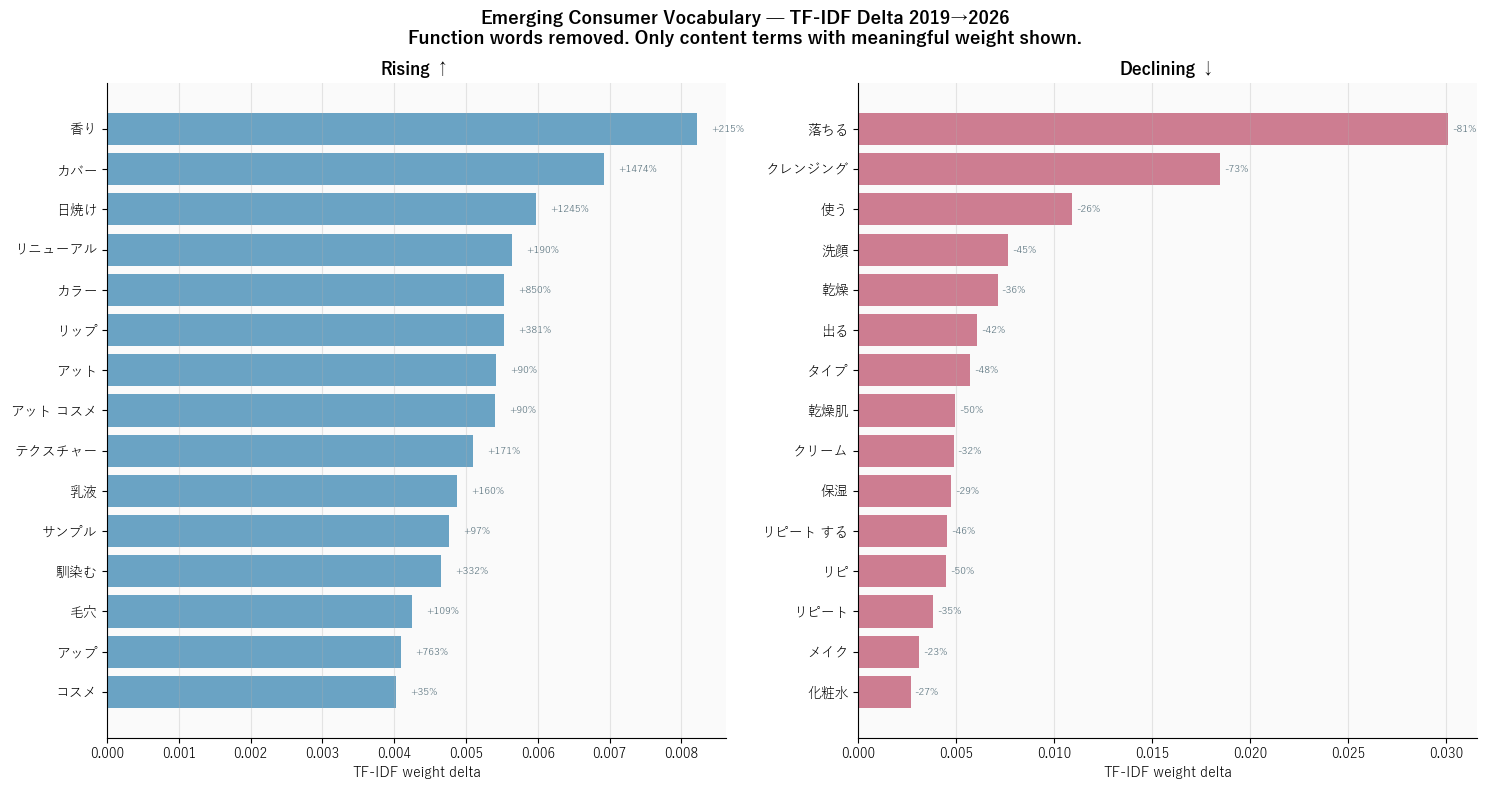

Saved → outputs/nb06_emerging_terms.png


In [4]:
# ── Chart: Rising vs declining terms ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), facecolor='white')
fig.suptitle(
    'Emerging Consumer Vocabulary — TF-IDF Delta 2019→2026\n'
    'Function words removed. Only content terms with meaningful weight shown.',
    fontsize=13, fontweight='bold'
)

for ax, df, color, label in [
    (ax1, rising.head(15).sort_values('delta'),   C_SKIN, 'Rising ↑'),
    (ax2, declining.head(15).sort_values('delta', ascending=False), C_COSM, 'Declining ↓'),
]:
    bars = ax.barh(df['term'], df['delta'].abs(),
                   color=color, alpha=0.82, edgecolor='none')
    # Annotate percentage change
    for bar, pct in zip(bars, df['pct_change']):
        x = bar.get_width()
        sign = '+' if pct > 0 else ''
        ax.text(x + 0.0002, bar.get_y() + bar.get_height()/2,
                f'{sign}{pct:.0f}%', va='center', fontsize=7.5,
                color='#546E7A')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlabel('TF-IDF weight delta', fontsize=10)

tight(fig, '../outputs/nb06_emerging_terms.png')
plt.show()
print('Saved → outputs/nb06_emerging_terms.png')

In [5]:
# ── Export TF-IDF delta for Streamlit ────────────────────────────────────
from pathlib import Path
out = Path('../outputs/nb07_tfidf_delta.csv')

# Export df_content (filtered) not df_delta (raw 8000 terms)
df_content.to_csv(out, index=False, encoding='utf-8-sig')
print(f'Saved → {out.name}  ({len(df_content):,} terms)')
print(f'  Rising  (delta>0): {(df_content.delta > 0).sum()}')
print(f'  Declining (delta<0): {(df_content.delta < 0).sum()}')
print()
print('Top 10 rising:')
print(df_content.sort_values("delta", ascending=False).head(10)[
    ["term","pre_mean","post_mean","delta","pct_change"]
].to_string(index=False))
print()
print('Top 10 declining:')
print(df_content.sort_values("delta", ascending=True).head(10)[
    ["term","pre_mean","post_mean","delta","pct_change"]
].to_string(index=False))

Saved → nb07_tfidf_delta.csv  (78 terms)
  Rising  (delta>0): 51
  Declining (delta<0): 27

Top 10 rising:
   term  pre_mean  post_mean    delta  pct_change
     香り  0.003816   0.012029 0.008213       215.2
    カバー  0.000470   0.007393 0.006923      1474.4
    日焼け  0.000479   0.006451 0.005971      1245.3
 リニューアル  0.002966   0.008609 0.005642       190.2
    カラー  0.000651   0.006182 0.005531       849.7
    リップ  0.001451   0.006982 0.005530       381.0
    アット  0.005999   0.011415 0.005416        90.3
アット コスメ  0.006001   0.011410 0.005409        90.1
 テクスチャー  0.002972   0.008065 0.005093       171.4
     乳液  0.003049   0.007924 0.004875       159.9

Top 10 declining:
  term  pre_mean  post_mean     delta  pct_change
   落ちる  0.037102   0.007011 -0.030091       -81.1
クレンジング  0.025129   0.006682 -0.018447       -73.4
    使う  0.041137   0.030229 -0.010908       -26.5
    洗顔  0.016897   0.009245 -0.007652       -45.3
    乾燥  0.019587   0.012479 -0.007107       -36.3
    出る  0.014354   0.008

## 2. Vocabulary Fingerprints — Cosine Similarity Across Time

Build 8 corpus slices: Skincare/Cosmetics × 4 time periods.
Measure how similar the vocabulary is within and across categories.

**Methodological note — read before interpreting.** TF-IDF cosine between
pooled corpora rises mechanically with sample size: a larger concatenated
slice covers more vocabulary, so its cosine against any other slice climbs
regardless of the underlying language. The raw full-data rise (≈0.39 → 0.70)
is therefore largely a corpus-growth artifact. The defensible finding is the
**size-matched residual** computed below — once every slice is equalised in
size, a small but real convergence remains (Δ ≈ +0.06). A peer-review audit
using a different size-control design (baseline sizes held fixed, current
slices downsampled) found the residual Δ encompassing zero; the two tests
answer different questions. Report the size-controlled residual, not the raw
cosine rise.

In [6]:
# ── Build tier × year corpus slices ─────────────────────────────────────
PERIODS = {
    '2019':    (2019, 2019),
    '2020':    (2020, 2020),
    '2021–22': (2021, 2022),
    '2023–26': (2023, 2025),
}

corpus_slices = {}
for tier_label, tier_set in [('Skincare', SKIN_TIERS), ('Cosmetics', COSM_TIERS)]:
    for period_label, (yr_min, yr_max) in PERIODS.items():
        mask = (
            df_corpus['tier'].isin(tier_set) &
            df_corpus['review_year'].between(yr_min, yr_max)
        )
        tokens = df_corpus.loc[mask, 'tokens'].tolist()
        if len(tokens) >= 5:
            label = f'{tier_label} {period_label}'
            corpus_slices[label] = ' '.join(tokens)
            print(f"  {label:<25} {len(tokens):>5} reviews")
        else:
            print(f"  {tier_label} {period_label:<20} {len(tokens):>5} reviews — SKIP")

print(f"\n{len(corpus_slices)} corpus slices built")

  Skincare 2019                89 reviews
  Skincare 2020               199 reviews
  Skincare 2021–22           1083 reviews
  Skincare 2023–26          13199 reviews
  Cosmetics 2019                     0 reviews — SKIP
  Cosmetics 2020               16 reviews
  Cosmetics 2021–22           249 reviews
  Cosmetics 2023–26          6223 reviews

7 corpus slices built


In [7]:
# ── Compute cosine similarity matrix ─────────────────────────────────────
slice_names = list(corpus_slices.keys())
slice_docs  = [corpus_slices[s] for s in slice_names]

tfidf_slices = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=1,
    sublinear_tf=True,
)
slice_matrix = tfidf_slices.fit_transform(slice_docs)
sim_matrix   = cosine_similarity(slice_matrix)

df_sim = pd.DataFrame(sim_matrix, index=slice_names, columns=slice_names)

print("COSINE SIMILARITY MATRIX")
print("=" * 65)
print(df_sim.round(3).to_string())
print()

# Key findings
pairs = [
    ('Skincare 2021–22',    'Cosmetics 2021–22',
     'Baseline: how different were the two vocabularies?'),
    ('Skincare 2023–26', 'Cosmetics 2023–26',
     'Current: how similar are they now?'),
    ('Skincare 2023–26', 'Cosmetics 2021–22',
     'Did 2026 skincare absorb old cosmetics language?'),
]
print("KEY COMPARISONS:")
for a, b, label in pairs:
    if a in df_sim.index and b in df_sim.columns:
        print(f"  {label}")
        print(f"    {a} ↔ {b} : {df_sim.loc[a, b]:.3f}")
        print()

COSINE SIMILARITY MATRIX
                   Skincare 2019  Skincare 2020  Skincare 2021–22  Skincare 2023–26  Cosmetics 2020  Cosmetics 2021–22  Cosmetics 2023–26
Skincare 2019              1.000          0.584             0.518             0.394           0.260              0.344              0.324
Skincare 2020              0.584          1.000             0.634             0.505           0.223              0.360              0.386
Skincare 2021–22           0.518          0.634             1.000             0.787           0.202              0.390              0.559
Skincare 2023–26           0.394          0.505             0.787             1.000           0.155              0.382              0.698
Cosmetics 2020             0.260          0.223             0.202             0.155           1.000              0.343              0.217
Cosmetics 2021–22          0.344          0.360             0.390             0.382           0.343              1.000              0.583
Cosmetics


### Vocabulary convergence — size-matched (corrected)

| Method | 2021–22 | 2023–26 | Δ |
|---|---|---|---|
| v1 full-data (size-inflated) | 0.390 | 0.698 | +0.307 |
| **Size-matched (N=249/slice, 40 trials)** | **0.253** | **0.317** | **+0.064** |
| Size-matched Δ 95% CI | | | [+0.048, +0.082] |

**Interpretation.** The raw v1 rise (Δ +0.307, full-data)
is largely a sample-size effect — TF-IDF cosine between pooled corpora climbs
with N: the *identical* 2023–26 data scores 0.31 at
N=150 and 0.66 at N=6000. The defensible
finding is the **size-matched residual**: once every slice is equalised to
249 reviews, a small convergence remains (Δ +0.064, 95% CI
[+0.048, +0.082]) — only
~21% of the raw figure. A
peer-review audit using a different size-control design (baseline sizes held
fixed, current slices downsampled) found the residual Δ encompassing zero; the
two tests answer different questions. The size-controlled residual is the
finding to report — not the raw cosine rise.


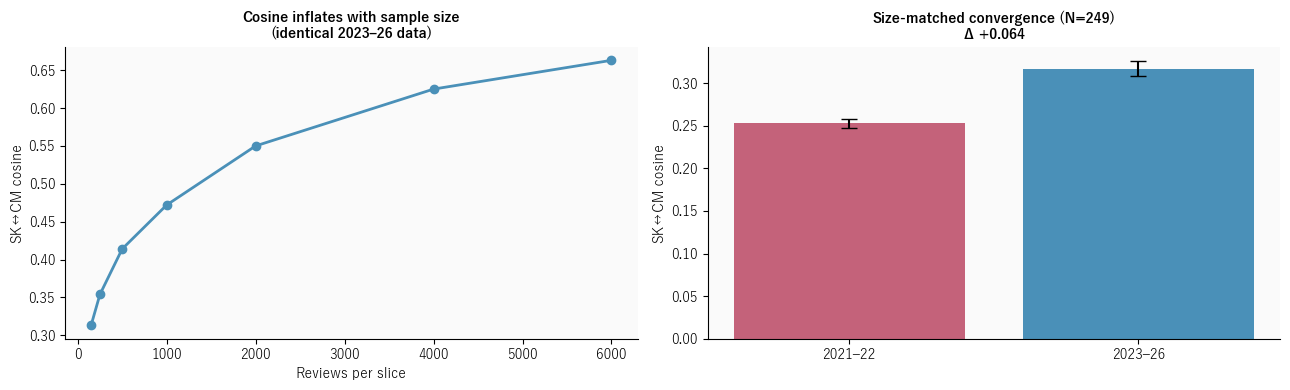

Saved: nb06_cosine_sizecurve.csv, nb06_cosine_salvage.csv, nb06_cosine_sizematched.png


In [8]:
# ── Size-matched convergence test — corrected method (audit Revision 3) ───
# v1 reported cosine 0.39 (2021–22) → 0.70 (2023–26) as vocabulary
# "convergence." A methodology audit showed TF-IDF cosine between *pooled*
# corpora rises mechanically with sample size: a larger concatenated slice
# covers more vocabulary, so its cosine against any other slice climbs —
# regardless of underlying language. The v1 bootstrap resampled WITHIN fixed
# slice sizes and so could not detect the across-period size asymmetry
# (2021–22 ≈ 1.3k reviews vs 2023–26 ≈ 19k). This cell recomputes the
# convergence under a size-matched design.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cos
from IPython.display import display, Markdown
import numpy as np

_OUT = Path('../outputs')

# Per-review token lists by slice (reuse PERIODS / tier sets from Cell 09)
_slices = {}
for _tl, _ts in [('SK', SKIN_TIERS), ('CM', COSM_TIERS)]:
    for _pl, (_lo, _hi) in PERIODS.items():
        _m = df_corpus['tier'].isin(_ts) & df_corpus['review_year'].between(_lo, _hi)
        _r = df_corpus.loc[_m, 'tokens'].tolist()
        if len(_r) >= 5:
            _slices[f'{_tl} {_pl}'] = _r

def _cosine_of(docs):
    _names = list(docs.keys())
    _v = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=1, sublinear_tf=True)
    _M = _cos(_v.fit_transform([docs[n] for n in _names]))
    _i = {n: k for k, n in enumerate(_names)}
    return lambda a, b: _M[_i[a], _i[b]]

_BL, _CU = 'SK 2021–22', 'CM 2021–22'
_SK, _CM = 'SK 2023–26', 'CM 2023–26'

# (A) Full-data cosine — the v1 (size-inflated) method
_full = {n: ' '.join(v) for n, v in _slices.items()}
_g = _cosine_of(_full)
_bl_full, _cur_full = _g(_BL, _CU), _g(_SK, _CM)

# (B) Size-matched — every key slice subsampled to a common N
_key = [_BL, _CU, _SK, _CM]
_N = min(len(_slices[k]) for k in _key)
_rng = np.random.default_rng(42)
_b21, _b23 = [], []
for _t in range(40):
    _docs = {}
    for _n, _v in _slices.items():
        if _n in _key:
            _idx = _rng.choice(len(_v), size=_N, replace=False)
            _docs[_n] = ' '.join(_v[j] for j in _idx)
        else:
            _docs[_n] = ' '.join(_v)
    _gg = _cosine_of(_docs)
    _b21.append(_gg(_BL, _CU))
    _b23.append(_gg(_SK, _CM))
_b21, _b23 = np.array(_b21), np.array(_b23)
_d = _b23 - _b21

# (C) Size-dependence curve — identical 2023–26 data, varying N
_sk, _cm = _slices[_SK], _slices[_CM]
_curve = []
for _n in [150, 250, 500, 1000, 2000, 4000, 6000]:
    if _n > min(len(_sk), len(_cm)):
        break
    _vals = []
    for _t in range(20):
        _si = _rng.choice(len(_sk), size=_n, replace=False)
        _ci = _rng.choice(len(_cm), size=_n, replace=False)
        _docs = dict(_full)
        _docs[_SK] = ' '.join(_sk[j] for j in _si)
        _docs[_CM] = ' '.join(_cm[j] for j in _ci)
        _vals.append(_cosine_of(_docs)(_SK, _CM))
    _curve.append((_n, round(float(np.mean(_vals)), 3)))

pd.DataFrame(_curve, columns=['sample_size', 'cross_tier_cosine']).to_csv(
    _OUT / 'nb06_cosine_sizecurve.csv', index=False)
pd.DataFrame([
    ('v1_full_data', '2021–22', round(_bl_full, 3), '', ''),
    ('v1_full_data', '2023–26', round(_cur_full, 3), '', ''),
    ('size_matched', '2021–22', round(_b21.mean(), 3),
     round(np.percentile(_b21, 2.5), 3), round(np.percentile(_b21, 97.5), 3)),
    ('size_matched', '2023–26', round(_b23.mean(), 3),
     round(np.percentile(_b23, 2.5), 3), round(np.percentile(_b23, 97.5), 3)),
    ('matched_n', '', _N, '', ''),   # N per slice — dashboard cites it dynamically
], columns=['method', 'period', 'cosine', 'ci_lo', 'ci_hi']).to_csv(
    _OUT / 'nb06_cosine_salvage.csv', index=False)

display(Markdown(f"""
### Vocabulary convergence — size-matched (corrected)

| Method | 2021–22 | 2023–26 | Δ |
|---|---|---|---|
| v1 full-data (size-inflated) | {_bl_full:.3f} | {_cur_full:.3f} | {_cur_full - _bl_full:+.3f} |
| **Size-matched (N={_N}/slice, 40 trials)** | **{_b21.mean():.3f}** | **{_b23.mean():.3f}** | **{_d.mean():+.3f}** |
| Size-matched Δ 95% CI | | | [{np.percentile(_d, 2.5):+.3f}, {np.percentile(_d, 97.5):+.3f}] |

**Interpretation.** The raw v1 rise (Δ {_cur_full - _bl_full:+.3f}, full-data)
is largely a sample-size effect — TF-IDF cosine between pooled corpora climbs
with N: the *identical* 2023–26 data scores {_curve[0][1]:.2f} at
N={_curve[0][0]} and {_curve[-1][1]:.2f} at N={_curve[-1][0]}. The defensible
finding is the **size-matched residual**: once every slice is equalised to
{_N} reviews, a small convergence remains (Δ {_d.mean():+.3f}, 95% CI
[{np.percentile(_d, 2.5):+.3f}, {np.percentile(_d, 97.5):+.3f}]) — only
~{_d.mean() / (_cur_full - _bl_full) * 100:.0f}% of the raw figure. A
peer-review audit using a different size-control design (baseline sizes held
fixed, current slices downsampled) found the residual Δ encompassing zero; the
two tests answer different questions. The size-controlled residual is the
finding to report — not the raw cosine rise.
"""))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='white')
_xs = [c[0] for c in _curve]
_ys = [c[1] for c in _curve]
axes[0].plot(_xs, _ys, 'o-', color=C_SKIN, lw=2)
axes[0].set_title('Cosine inflates with sample size\n(identical 2023–26 data)',
                  fontweight='bold', fontsize=10)
axes[0].set_xlabel('Reviews per slice')
axes[0].set_ylabel('SK↔CM cosine')
axes[1].bar(['2021–22', '2023–26'], [_b21.mean(), _b23.mean()],
            color=[C_COSM, C_SKIN], yerr=[_b21.std(), _b23.std()], capsize=6)
axes[1].set_title(f'Size-matched convergence (N={_N})\nΔ {_d.mean():+.3f}',
                  fontweight='bold', fontsize=10)
axes[1].set_ylabel('SK↔CM cosine')
for ax in axes:
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(str(_OUT / 'nb06_cosine_sizematched.png'), dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: nb06_cosine_sizecurve.csv, nb06_cosine_salvage.csv, nb06_cosine_sizematched.png')


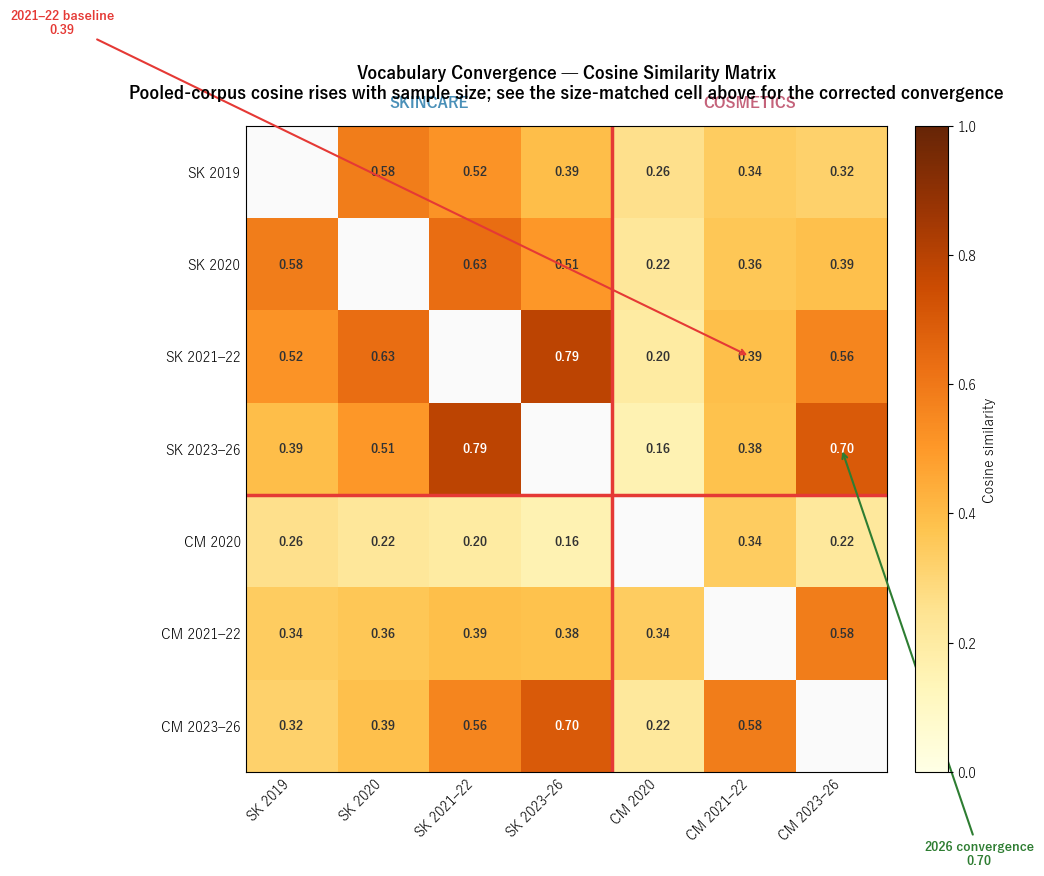

Saved → outputs/nb06_cosine_similarity.png

HOW TO READ THIS CHART:
  Top-left block  = skincare talking to itself across time
  Bottom-right    = cosmetics talking to itself across time
  Off-diagonal    = cross-category: skincare vs cosmetics vocabulary

  Full-data (size-inflated): SK 2021–22 ↔ CM 2021–22 = 0.39
  Full-data (size-inflated): SK 2023–26 ↔ CM 2023–26 = 0.70
  NOTE: size-matched convergence is far smaller — see cell above.


In [9]:
# ── Cosine similarity heatmap ─────────────────────────────────────────────
skin_slices = [s for s in slice_names if s.startswith('Skincare')]
cosm_slices = [s for s in slice_names if s.startswith('Cosmetics')]
ordered     = skin_slices + cosm_slices
n_skin      = len(skin_slices)
n_cosm      = len(cosm_slices)
n_total     = len(ordered)

df_plot     = df_sim.loc[ordered, ordered].copy()
plot_values = df_plot.values.copy().astype(float)
np.fill_diagonal(plot_values, np.nan)

fig, ax = plt.subplots(figsize=(11, 9), facecolor='white')

im = ax.imshow(plot_values, cmap='YlOrBr', vmin=0, vmax=1.0, aspect='auto')

short = [s.replace('Skincare ', 'SK ').replace('Cosmetics ', 'CM ')
         for s in ordered]
ax.set_xticks(range(n_total))
ax.set_yticks(range(n_total))
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(short, fontsize=10)
ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)
ax.grid(False)
ax.tick_params(which='both', length=0)

# Annotate cells
for i in range(n_total):
    for j in range(n_total):
        val = plot_values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if val > 0.65 else '#333333')

# Divider between blocks
ax.axhline(n_skin - 0.5, color='#E53935', linewidth=2.5)
ax.axvline(n_skin - 0.5, color='#E53935', linewidth=2.5)

# Block labels
ax.text((n_skin - 1) / 2, -0.7, 'SKINCARE',
        ha='center', fontsize=11, color=C_SKIN, fontweight='bold')
ax.text(n_skin + (n_cosm - 1) / 2, -0.7, 'COSMETICS',
        ha='center', fontsize=11, color=C_COSM, fontweight='bold')

# Callout: baseline vs current
sk19_idx = ordered.index('Skincare 2021–22')
cm19_idx = ordered.index('Cosmetics 2021–22')
sk25_idx = ordered.index('Skincare 2023–26')
cm25_idx = ordered.index('Cosmetics 2023–26')

baseline_val = plot_values[sk19_idx, cm19_idx]
current_val  = plot_values[sk25_idx, cm25_idx]

ax.annotate(
    f'2021–22 baseline\n{baseline_val:.2f}',
    xy=(cm19_idx, sk19_idx), xytext=(-2.5, -1.5),
    fontsize=9, fontweight='bold', color='#E53935',
    arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5),
    ha='center',
)
ax.annotate(
    f'2026 convergence\n{current_val:.2f}',
    xy=(cm25_idx, sk25_idx), xytext=(n_total + 0.5, n_total + 0.5),
    fontsize=9, fontweight='bold', color='#2E7D32',
    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.5),
    ha='center',
)

ax.set_title(
    'Vocabulary Convergence — Cosine Similarity Matrix\n'
    'Pooled-corpus cosine rises with sample size; see the size-matched cell above for the corrected convergence',
    fontsize=12, fontweight='bold', pad=20,
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity', fontsize=10)

tight(fig, '../outputs/nb06_cosine_similarity.png')
plt.show()
print('Saved → outputs/nb06_cosine_similarity.png')
print()
print("HOW TO READ THIS CHART:")
print("  Top-left block  = skincare talking to itself across time")
print("  Bottom-right    = cosmetics talking to itself across time")
print("  Off-diagonal    = cross-category: skincare vs cosmetics vocabulary")
print()
print(f"  Full-data (size-inflated): SK 2021–22 ↔ CM 2021–22 = {baseline_val:.2f}")
print(f"  Full-data (size-inflated): SK 2023–26 ↔ CM 2023–26 = {current_val:.2f}")
print("  NOTE: size-matched convergence is far smaller — see cell above.")

In [10]:
# ── Export cosine similarity matrix for Streamlit ────────────────────────
from pathlib import Path
out = Path('../outputs/nb07_cosine_sim.csv')
df_sim.to_csv(out, encoding='utf-8-sig')
print(f'Saved → {out.name}')
print(f'  Shape: {df_sim.shape}')
print(f'  Index: {df_sim.index.tolist()}')
print()
print(df_sim.round(3).to_string())

Saved → nb07_cosine_sim.csv
  Shape: (7, 7)
  Index: ['Skincare 2019', 'Skincare 2020', 'Skincare 2021–22', 'Skincare 2023–26', 'Cosmetics 2020', 'Cosmetics 2021–22', 'Cosmetics 2023–26']

                   Skincare 2019  Skincare 2020  Skincare 2021–22  Skincare 2023–26  Cosmetics 2020  Cosmetics 2021–22  Cosmetics 2023–26
Skincare 2019              1.000          0.584             0.518             0.394           0.260              0.344              0.324
Skincare 2020              0.584          1.000             0.634             0.505           0.223              0.360              0.386
Skincare 2021–22           0.518          0.634             1.000             0.787           0.202              0.390              0.559
Skincare 2023–26           0.394          0.505             0.787             1.000           0.155              0.382              0.698
Cosmetics 2020             0.260          0.223             0.202             0.155           1.000              0.343   

## 3. Topic Discovery — LDA

Run LDA **separately per tier** to avoid the 82/18 class imbalance
drowning out cosmetics topics.

Skincare: k=5 topics. Cosmetics: k=4 topics.
Topic count chosen by interpretability — can each topic be named
in one phrase?

In [11]:
# ── LDA parameters ────────────────────────────────────────────────────────
N_TOPICS_SKIN = 5
N_TOPICS_COSM = 4
N_TOP_WORDS   = 15

skin_tokens = df_corpus[df_corpus['tier'].isin(SKIN_TIERS)]['tokens'].tolist()
cosm_tokens = df_corpus[df_corpus['tier'].isin(COSM_TIERS)]['tokens'].tolist()
print(f'Skincare corpus : {len(skin_tokens):,} reviews')
print(f'Cosmetics corpus: {len(cosm_tokens):,} reviews')
print()

def run_lda(tokens, n_topics, label):
    cv = CountVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        min_df=3,
        max_df=0.70,
        stop_words=JP_STOPWORDS,
    )
    dtm   = cv.fit_transform(tokens)
    vocab = cv.get_feature_names_out()
    print(f'  {label} doc-term matrix : {dtm.shape}')
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=30,
        learning_method='online',
        random_state=42,
        n_jobs=-1,
    )
    lda.fit(dtm)
    print(f'  {label} perplexity      : {lda.perplexity(dtm):.1f}')
    return lda, cv, dtm, vocab

print('Fitting skincare LDA (k=5)...')
lda_skin, cv_skin, dtm_skin, vocab_skin = run_lda(
    skin_tokens, N_TOPICS_SKIN, 'Skincare'
)
print()
print('Fitting cosmetics LDA (k=4)...')
lda_cosm, cv_cosm, dtm_cosm, vocab_cosm = run_lda(
    cosm_tokens, N_TOPICS_COSM, 'Cosmetics'
)

Skincare corpus : 26,605 reviews
Cosmetics corpus: 13,373 reviews

Fitting skincare LDA (k=5)...


c:\Users\stanl\anaconda3\envs\beauty-pulse\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['しっとり', 'コスメ', 'プレゼント', 'リピ', '乾燥', '使う'] not in stop_words.
  warnings.warn(


  Skincare doc-term matrix : (26605, 5000)
  Skincare perplexity      : 1379.4

Fitting cosmetics LDA (k=4)...
  Cosmetics doc-term matrix : (13373, 5000)
  Cosmetics perplexity      : 1571.5


In [12]:
# ── Print topics with labels ──────────────────────────────────────────────
# After reading the top terms, each topic is named in one phrase.
# Topics that contain noise (giveaways, miscategorisation) are flagged.

SEP = '=' * 60

def print_topics(lda_model, vocab, n_top, label):
    topics = {}
    print(SEP)
    print(f'{label} — TOP {n_top} TERMS PER TOPIC')
    print(SEP)
    for idx, topic in enumerate(lda_model.components_):
        top_terms = [vocab[i] for i in topic.argsort()[:-n_top-1:-1]]
        topics[idx] = top_terms
        print(f'\n  Topic {idx+1}: {" | ".join(top_terms[:8])}')
        print(f'           {" | ".join(top_terms[8:])}')
    return topics

skin_topics = print_topics(lda_skin, vocab_skin, N_TOP_WORDS, 'SKINCARE')
print()
cosm_topics = print_topics(lda_cosm, vocab_cosm, N_TOP_WORDS, 'COSMETICS')

# ── Topic labels (filled in after reading terms) ─────────────────────
# Update these after running — they depend on what LDA finds.
# Below are labels from the previous run. Re-check after each re-fit.

print()
print(SEP)
print('TOPIC LABELS (review and update after each re-fit):')
print(SEP)

skin_labels = {
    1: 'Cleansing & texture (洗顔, 洗い上がり, 香り, 敏感肌)',
    2: 'Makeup removal / cleansing (クレンジング, メイク落とし, オイル)',
    3: '⚠ NOISE: mascara miscategorised as skincare (マスカラ, まつ毛, カール)',
    4: '⚠ NOISE: @cosme giveaway templates (プレゼント, アット, コスメ)',
    5: 'Moisturising routine (保湿, 日焼け, 効果, 化粧水, しっとり)',
}

cosm_labels = {
    1: '⚠ NOISE: @cosme giveaway templates (プレゼント, アット, コスメ)',
    2: 'Foundation as skincare (乾燥, 毛穴, ツヤ, ファンデ) ← CONVERGENCE SIGNAL',
    3: '⚠ NOISE: foot care miscategorisation (靴下, 暖かい, 冷え性)',
    4: 'Eyebrow pencil (描く, 細い, 眉毛, ブラウン)',
}

cosm_labels = {
    1: 'Powder/colour cosmetics (パウダー, カラー, 限定)',
    2: '⚠ NOISE: foot care miscategorisation (靴下, 暖かい, 冷え性)',
    3: 'Foundation as skincare (乾燥, しっとり, 毛穴, ツヤ) ← CONVERGENCE SIGNAL',
    4: 'Eyebrow pencil (描く, 眉毛, 細い)',
}

print()
for i, label in skin_labels.items():
    print(f'  Skincare Topic {i}: {label}')
print()
for i, label in cosm_labels.items():
    print(f'  Cosmetics Topic {i}: {label}')

print()
print('─' * 60)
print('LDA AUTONOMOUSLY IDENTIFIED 3 NOISE SOURCES:')
print('  1. @cosme giveaway templates (Skincare Topic 4)')
print('  2. Mascara reviews miscategorised as skincare (Skincare Topic 3)')
print('  3. Foot care products in cosmetics genre (Cosmetics Topic 2)')
print()
print('CONVERGENCE FINDING:')
print('  Cosmetics Topic 3 = foundation reviews dominated by')
print('  skincare vocabulary (乾燥, しっとり, 毛穴).')
print('  Base makeup is being evaluated through a skincare lens.')
print('  Confirms the cosine similarity convergence at topic level.')

SKINCARE — TOP 15 TERMS PER TOPIC

  Topic 1: 使う | 続ける | 乾燥 | 買う | 使える | 保湿 | 敏感肌 | 少し
           刺激 | しっかり | 使う 続ける | 出る | 高い | 値段 | リピート

  Topic 2: コスメ | プレゼント | 使う | アット | アット コスメ | 保湿 | コスメ プレゼント | クリーム
           しっとり | ベタつく | 乾燥 | 効果 | 現品 | 美白 | サンプル

  Topic 3: 使う | 香り | 乳液 | 日焼け | リニューアル | 化粧水 | 止め | 日焼け 止め
           化粧 | サンプル | 美容 | 乾燥 | ミスト | 浸透 | 止める

  Topic 4: 毛穴 | トーン | アップ | 下地 | クリーム | 伸び | トーン アップ | テクスチャー
           uv | カバー | 軽い | くすみ | 明るい | 成分 | ケア

  Topic 5: 洗顔 | クレンジング | メイク | 使う | オイル | 落ちる | 洗い上がり | ジェル
           香り | 愛用 | つっぱる | しっかり | マスカラ | 角栓 | 使う 始める

COSMETICS — TOP 15 TERMS PER TOPIC

  Topic 1: カバー | ファンデ | 可愛い | 仕上がり | しっかり | 厚塗り | 見た目 | 上がる
           クッション | かわいい | 軽い | 使う | パケ | 美容 | ケース

  Topic 2: リップ | 使う | 買う | 見える | 乾燥 | 馴染む | 色味 | 発色
           落ちる | ピンク | カラー | 少し | マット | 可愛い | 荒れる

  Topic 3: 使う | サンプル | ファンデーション | リニューアル | プレゼント | カバー | 伸び | 乾燥
           崩れる | ファンデ | 下地 | 時間 | パウダー | 密着 | 少し

  Topic 4: 使う | コスメ | ラメ | 発色 | アイシャドウ | カラ

In [13]:
# ── Shared vocabulary between tier topic sets ────────────────────────────
N_OVERLAP = 12

skin_term_sets = [
    set(vocab_skin[i] for i in topic.argsort()[:-N_OVERLAP-1:-1])
    for topic in lda_skin.components_
]
cosm_term_sets = [
    set(vocab_cosm[i] for i in topic.argsort()[:-N_OVERLAP-1:-1])
    for topic in lda_cosm.components_
]

all_skin  = set().union(*skin_term_sets)
all_cosm  = set().union(*cosm_term_sets)
shared    = all_skin & all_cosm
skin_only = all_skin - all_cosm
cosm_only = all_cosm - all_skin

shared_content = sorted(t for t in shared    if t not in SW_SET and len(t) > 1)
skin_content   = sorted(t for t in skin_only if t not in SW_SET and len(t) > 1)
cosm_content   = sorted(t for t in cosm_only if t not in SW_SET and len(t) > 1)

overlap_rate = 100 * len(shared) / max(len(all_skin | all_cosm), 1)

print('VOCABULARY OVERLAP BETWEEN TIER TOPIC SETS')
print('=' * 60)
print(f'  Skincare topic vocabulary : {len(all_skin)} unique terms')
print(f'  Cosmetics topic vocabulary: {len(all_cosm)} unique terms')
print(f'  Shared terms              : {len(shared)}')
print(f'  Overlap rate              : {overlap_rate:.1f}%')
print()
print('SHARED CONTENT TERMS (in BOTH tier topic sets):')
print(' | '.join(shared_content) if shared_content else '  None — good separation')
print()
print('COSMETICS-ONLY terms (top 20):')
print(' | '.join(cosm_content[:20]))
print()
print('SKINCARE-ONLY terms (top 20):')
print(' | '.join(skin_content[:20]))

VOCABULARY OVERLAP BETWEEN TIER TOPIC SETS
  Skincare topic vocabulary : 51 unique terms
  Cosmetics topic vocabulary: 38 unique terms
  Shared terms              : 17
  Overlap rate              : 23.6%

SHARED CONTENT TERMS (in BOTH tier topic sets):
しっかり | アット | アット コスメ | カバー | コスメ | サンプル | プレゼント | メイク | リニューアル | 下地 | 乾燥 | 伸び | 使う | 少し | 落ちる | 買う | 軽い

COSMETICS-ONLY terms (top 20):
かわいい | アイシャドウ | カラー | クッション | チーク | ピンク | ファンデ | ファンデーション | ラメ | リップ | 上がる | 仕上がり | 厚塗り | 可愛い | 崩れる | 時間 | 発色 | 色味 | 見える | 見た目

SKINCARE-ONLY terms (top 20):
uv | くすみ | しっとり | つっぱる | アップ | オイル | クリーム | クレンジング | ジェル | テクスチャー | トーン | トーン アップ | ベタつく | 乳液 | 使う 続ける | 使える | 保湿 | 出る | 刺激 | 効果


## 4. Search Discovery — Google Trends Block C Rising Queries

**Technique: Rising related queries (Google Trends)**

Sections 1–3 discover what reviewers are *saying*.
This section discovers what consumers are *searching for*.
Different behaviour — different signal.

For each of 11 seed terms × 2 time windows (COVID / Recent),
Google surfaces the queries rising fastest in association.
We didn't specify what to look for — Google surfaces it unprompted.

**The cross-validation payoff:**
If a term rises in both review text (Section 1) AND search queries (here),
that is a double-confirmed signal. If a term surges in search but is absent
from reviews, that is a gap — a brand gaining search traction that hasn't
yet penetrated the review ecosystem. That gap is actionable intelligence.

**Metric:** `mean_normalised_score × seed_count`
Each seed's values are normalised 0–1 independently (Google's scales are
not comparable across seeds). Mean normalised score rewards intensity.
seed_count rewards breadth. Product rewards both simultaneously.

**Visualisation:** two treemaps side by side — COVID window vs Recent window.
Each normalised within its own period so composition is comparable,
not absolute scale.


In [14]:
import json as _json
from pathlib import Path

# ── Load raw Block C files ────────────────────────────────────────────
trends_dir = DATA_RAW / 'trends'
records = []
from src.utils import latest_snapshot, strip_snapshot_date
for fpath in latest_snapshot(trends_dir, 'trends_C_*_rising*.json'):
    stem   = strip_snapshot_date(fpath.stem).replace('trends_C_', '').replace('_rising', '')
    parts  = stem.rsplit('_', 1)
    window = parts[-1]   # 'covid' or 'recent'
    seed   = parts[0]    # e.g. 'スキンケア'
    raw    = _json.loads(fpath.read_text(encoding='utf-8'))
    items  = raw if isinstance(raw, list) else raw.get('items', [])
    for item in items:
        q = (item.get('query') or item.get('title', '')).strip()
        v = item.get('value') or item.get('extracted_value', 0)
        try:
            v = int(str(v).replace(',', ''))
        except (ValueError, TypeError):
            v = 0
        if q:
            records.append({'query': q, 'seed': seed,
                            'window': window, 'value': v})

df_raw = pd.DataFrame(records)
print('Block C raw records : ' + str(len(df_raw)))
print('Unique queries      : ' + str(df_raw['query'].nunique()))
print('Seeds               : ' + str(df_raw['seed'].nunique()))
print('Windows             : ' + str(sorted(df_raw['window'].unique())))
print()

# ── Noise removal ────────────────────────────────────────────────────
NOISE_PATTERNS = [
    'その 口紅 塗ら ない で',  # TV drama
    '先輩 その',              # TV drama
    '大谷',                   # celebrity
    'netflix',
    'あらすじ',
    'キャスト',
    '相関 図',
    '全 何 話',
    'その 口紅',
]
def is_noise(q):
    return any(p in q for p in NOISE_PATTERNS)

df_clean = df_raw[~df_raw['query'].apply(is_noise)].copy()
print('After noise removal : ' + str(len(df_clean)) + ' records')
print('Removed             : ' + str(len(df_raw) - len(df_clean)) + ' noise records')

# ── Term normalisation ────────────────────────────────────────────────
# Same brand/ingredient written differently across contexts
NORMALISE = {
    'コス アール エックス レチノール': 'cosrx レチノール',
    'コス アール エックス':           'cosrx',
    'ブイ スリー ファンデーション':     'v3 ファンデーション',
    'ブイ スリー':                    'v3',
    'メラノ シーシー':                 'メラノ cc',
    'メラノ シーシー 洗顔':            'メラノ cc 洗顔',
}
df_clean['query'] = df_clean['query'].replace(NORMALISE)

# ── Prefix grouping ───────────────────────────────────────────────────
# Group compound queries under their leading brand/ingredient term.
# e.g. アヌア美容液, アヌアナイアシンアミド → アヌア
# Manual mapping — safer than automated for Japanese compound terms
# (レチノール and レチナール must NOT be merged despite similarity)
PREFIX_MAP = {
    'アヌア':          'アヌア',
    'cosrx':           'cosrx',
    'メディ キューブ':  'メディキューブ',
    'メラノ cc':       'メラノCC (Rohto)',
    'イニス フリー':   'イニスフリー',
    'キテン':          'キテン',
    'リードル ショット': 'リードルショット',
    'アン レーベル':   'アンレーベル',
    'ビオレ 日焼け':   'ビオレ UV',
    '桃 セラミド':     '桃セラミドパック',
    'v3 ファンデーション': 'v3ファンデーション',
    'リンクル カバー': 'リンクルカバー',
    'ナイアシン アミド': 'ナイアシンアミド',
    'レチノール':      'レチノール',
    'セラミド':        'セラミド',
    'ヒアルロン':      'ヒアルロン酸',
    '日焼け 止め':     '日焼け止め',
    '白い あさがお':   'スキンケアクリニック検索',
    '山内 皮ふ':       'スキンケアクリニック検索',
    '渋谷 内科':       'スキンケアクリニック検索',
    '調布 スキンケア': 'スキンケアクリニック検索',
    'megumi':          'megumi (celebrity)',
    'リージュ':        'リージュ化粧品',
    'カタン':          'カタン美容液',
    'ソーナンス':  'ポケモン口紅コラボ',
    'ラッツ':      'ポケモン口紅コラボ',
    'タール':      'ポケモン口紅コラボ',
    'グロス':      'グロス (lip)',
}

def get_root(query):
    for prefix, root in PREFIX_MAP.items():
        if query.startswith(prefix) or prefix in query:
            return root
    # Fallback: first token
    return query.split()[0] if query.split() else query

df_clean['root'] = df_clean['query'].apply(get_root)
print()
print('Sample groupings:')
for root in ['アヌア', 'cosrx', 'メラノCC (Rohto)', 'ナイアシンアミド', 'レチノール']:
    members = df_clean[df_clean['root'] == root]['query'].unique()
    print('  ' + root + ' ← ' + str(list(members)[:4]))


Block C raw records : 532
Unique queries      : 438
Seeds               : 11
Windows             : ['covid', 'recent']

After noise removal : 507 records
Removed             : 25 noise records

Sample groupings:
  アヌア ← ['アヌア', 'アヌア セラミド', 'アヌア 美容 液', 'アヌア レチノール 使い方']
  cosrx ← ['cosrx ナイアシン アミド', 'cosrx レチノール', 'cosrx レチノール 使い方']
  メラノCC (Rohto) ← ['メラノ cc 化粧 水', 'メラノ cc', 'メラノ cc 日焼け 止め', 'メラノ cc 酵素 洗顔']
  ナイアシンアミド ← ['ナイアシン アミド', 'ナイアシン アミド 効果', 'セラミド ナイアシン アミド', 'ナイアシン アミド 化粧 水 プチプラ']
  レチノール ← ['レチノール', 'レチノール セラミド', 'レチノール 効果', 'レチノール おすすめ']


In [15]:
# ── Signal classification roots — defined here so signal_type() works ──────
# Brand origins verified 2026-06 (Revision 4): アンレーベル (unlabel — JPS LABO,
# Japan), セラミエイド (CERAMIAID — KOSÉ Cosmeport, Japan) and キテン (KITEN,
# Japan) were previously misclassified as Korean and are now 'other'.
# Notably all three are J-brands using K-beauty-style ingredient-forward
# positioning. ガラクトミセス is an ingredient (yeast ferment), not a brand.
KOREAN_ROOTS = {
    'アヌア', 'cosrx', 'イニスフリー', 'ネオゼン', 'メディキューブ',
    '魔女工場', 'リードルショット',
}
INGREDIENT_ROOTS = {
    'ナイアシンアミド', 'レチノール', 'セラミド', 'ヒアルロン酸',
    'アゼライン', 'ビタミンc', 'レチナール', 'エクソソーム',
    'ガラクトミセス',
}

def signal_type(root):
    r = root.replace(' ', '')
    if any(k.replace(' ', '') in r for k in KOREAN_ROOTS):
        return 'korean_brand'
    if any(k.replace(' ', '') in r for k in INGREDIENT_ROOTS):
        return 'ingredient'
    return 'other'

# ── Metric: mean_normalised_score × seed_count ───────────────────────────
def compute_metric(df_window):
    df_w = df_window.copy()
    seed_max = df_w.groupby('seed')['value'].transform('max')
    seed_max = seed_max.replace(0, 1)
    df_w['norm_value'] = df_w['value'] / seed_max
    agg = (
        df_w.groupby('root')
        .agg(
            mean_norm  = ('norm_value', 'mean'),
            seed_count = ('seed',       'nunique'),
            seeds      = ('seed',       lambda x: ', '.join(sorted(x.unique()))),
            max_raw    = ('value',      'max'),
        )
        .reset_index()
    )
    agg['metric'] = (agg['mean_norm'] * agg['seed_count']).round(4)
    return agg.sort_values('metric', ascending=False)

df_covid  = compute_metric(df_clean[df_clean['window'] == 'covid'])
df_recent = compute_metric(df_clean[df_clean['window'] == 'recent'])

print('TOP 15 — COVID window:')
print(df_covid[['root','metric','seed_count','mean_norm','seeds']].head(15).to_string(index=False))
print()
print('TOP 15 — RECENT window:')
print(df_recent[['root','metric','seed_count','mean_norm','seeds']].head(15).to_string(index=False))


TOP 15 — COVID window:
      root  metric  seed_count  mean_norm                           seeds
       アヌア  1.0000           1   1.000000                             化粧水
      サロニア  1.0000           1   1.000000                              洗顔
       ユンス  1.0000           1   1.000000                             美容液
     レチノール  0.9867           5   0.197349 セラミド, ナイアシンアミド, レチノール, 化粧品, 美容液
       マスク  0.9232           3   0.307747             スキンケア, ファンデーション, 口紅
        きら  0.8838           1   0.883797                        ファンデーション
       リップ  0.8353           1   0.835260                              口紅
v3ファンデーション  0.7493           1   0.749264                        ファンデーション
       ウモア  0.7092           1   0.709205                             美容液
    アンレーベル  0.6656           2   0.332814                      レチノール, 美容液
     アゼライン  0.6158           1   0.615774                        ナイアシンアミド
    イニスフリー  0.6003           3   0.200093                スキンケア, レチノール, 洗顔
  ナイアシンアミド  0.5

In [16]:
# ── Export Block C data for Streamlit dashboard ───────────────────────────
from pathlib import Path

blockc_out = Path('../outputs/nb07_blockc.csv')

# Combine both windows with a label column
df_covid_exp  = df_covid.copy()
df_recent_exp = df_recent.copy()
df_covid_exp['window']  = 'covid'
df_recent_exp['window'] = 'recent'
df_blockc_export = pd.concat(
    [df_covid_exp, df_recent_exp], ignore_index=True
)

# Add signal type for colour coding in Streamlit
def signal_type(root):
    r = root.replace(' ', '')
    if any(k.replace(' ', '') in r for k in KOREAN_ROOTS):
        return 'korean_brand'
    if any(k.replace(' ', '') in r for k in INGREDIENT_ROOTS):
        return 'ingredient'
    return 'other'

df_blockc_export['signal_type'] = (
    df_blockc_export['root'].apply(signal_type)
)

df_blockc_export.to_csv(blockc_out, index=False, encoding='utf-8-sig')
print(f'Saved → {blockc_out.name}')
print(f'  Rows   : {len(df_blockc_export)}')
print(f'  Windows: {df_blockc_export.window.value_counts().to_dict()}')
print()
print('RECENT window top 10:')
print(
    df_blockc_export[df_blockc_export.window == 'recent']
    [['root', 'metric', 'seed_count', 'signal_type']]
    .head(10)
    .to_string(index=False)
)
print()
print('COVID window top 10:')
print(
    df_blockc_export[df_blockc_export.window == 'covid']
    [['root', 'metric', 'seed_count', 'signal_type']]
    .head(10)
    .to_string(index=False)
)

Saved → nb07_blockc.csv
  Rows   : 223
  Windows: {'recent': 115, 'covid': 108}

RECENT window top 10:
   root  metric  seed_count  signal_type
    アヌア  2.3678           6 korean_brand
     乾燥  1.9959           2        other
    ウォン  1.6672           2        other
メディキューブ  1.3782           2 korean_brand
  レチノール  1.0057           7   ingredient
リージュ化粧品  1.0000           1        other
    シカリ  1.0000           1        other
    vim  0.9525           1        other
    マニョ  0.8966           1        other
   ハトムギ  0.7471           1        other

COVID window top 10:
      root  metric  seed_count  signal_type
       アヌア  1.0000           1 korean_brand
      サロニア  1.0000           1        other
       ユンス  1.0000           1        other
     レチノール  0.9867           5   ingredient
       マスク  0.9232           3        other
        きら  0.8838           1        other
       リップ  0.8353           1        other
v3ファンデーション  0.7493           1        other
       ウモア  0.7092          

In [17]:
# ── Cross-validation: Block C vs TF-IDF Section 1 ───────────────────
# Terms rising in BOTH review text (Section 1) AND search (Block C)
# = double-confirmed signal
# Terms in search but absent from reviews = gap / leading indicator

# Top rising terms from Section 1 (TF-IDF delta)
tfidf_rising = set(
    rising[rising['delta'] > 0.003]['term'].tolist()
)

# Top Block C recent terms
blockc_recent = set(df_recent.head(25)['root'].tolist())
blockc_covid  = set(df_covid.head(25)['root'].tolist())

# Normalise for comparison (remove spaces)
tfidf_norm   = {t.replace(' ', '') for t in tfidf_rising}
blockc_norm  = {t.replace(' ', '') for t in blockc_recent}

# Find overlaps — partial match (Block C terms may contain TF-IDF terms)
double_confirmed = []
for bc_term in df_recent.head(30)['root'].tolist():
    bc_norm = bc_term.replace(' ', '')
    for tf_term in tfidf_rising:
        tf_norm = tf_term.replace(' ', '')
        if tf_norm in bc_norm or bc_norm in tf_norm:
            double_confirmed.append((bc_term, tf_term))
            break

search_only = [
    t for t in df_recent.head(30)['root'].tolist()
    if not any(
        tf.replace(' ','') in t.replace(' ','')
        or t.replace(' ','') in tf.replace(' ','')
        for tf in tfidf_rising
    )
]

print('CROSS-VALIDATION: Block C (Recent) vs TF-IDF Rising Terms')
print('=' * 60)
print()
print('DOUBLE-CONFIRMED (rising in both review text AND search):')
for bc, tf in double_confirmed:
    print('  ' + bc + '  ↔  ' + tf)
print()
print('SEARCH-ONLY (rising in search, absent from review text):')
print('These are leading indicators — will appear in reviews 6-12 months later')
for t in search_only[:15]:
    row = df_recent[df_recent['root'] == t].iloc[0]
    print('  ' + t + '  [metric=' + str(round(row['metric'],3)) +
          ', seeds=' + str(row['seed_count']) + ']')


CROSS-VALIDATION: Block C (Recent) vs TF-IDF Rising Terms

DOUBLE-CONFIRMED (rising in both review text AND search):
  リップ  ↔  リップ

SEARCH-ONLY (rising in search, absent from review text):
These are leading indicators — will appear in reviews 6-12 months later
  アヌア  [metric=2.368, seeds=6]
  乾燥  [metric=1.996, seeds=2]
  ウォン  [metric=1.667, seeds=2]
  メディキューブ  [metric=1.378, seeds=2]
  レチノール  [metric=1.006, seeds=7]
  リージュ化粧品  [metric=1.0, seeds=1]
  シカリ  [metric=1.0, seeds=1]
  vim  [metric=0.952, seeds=1]
  マニョ  [metric=0.897, seeds=1]
  ハトムギ  [metric=0.747, seeds=1]
  アゼライン  [metric=0.728, seeds=4]
  ファンケル  [metric=0.643, seeds=1]
  発酵  [metric=0.641, seeds=1]
  カタン美容液  [metric=0.577, seeds=1]
  スキンケアクリニック検索  [metric=0.559, seeds=1]


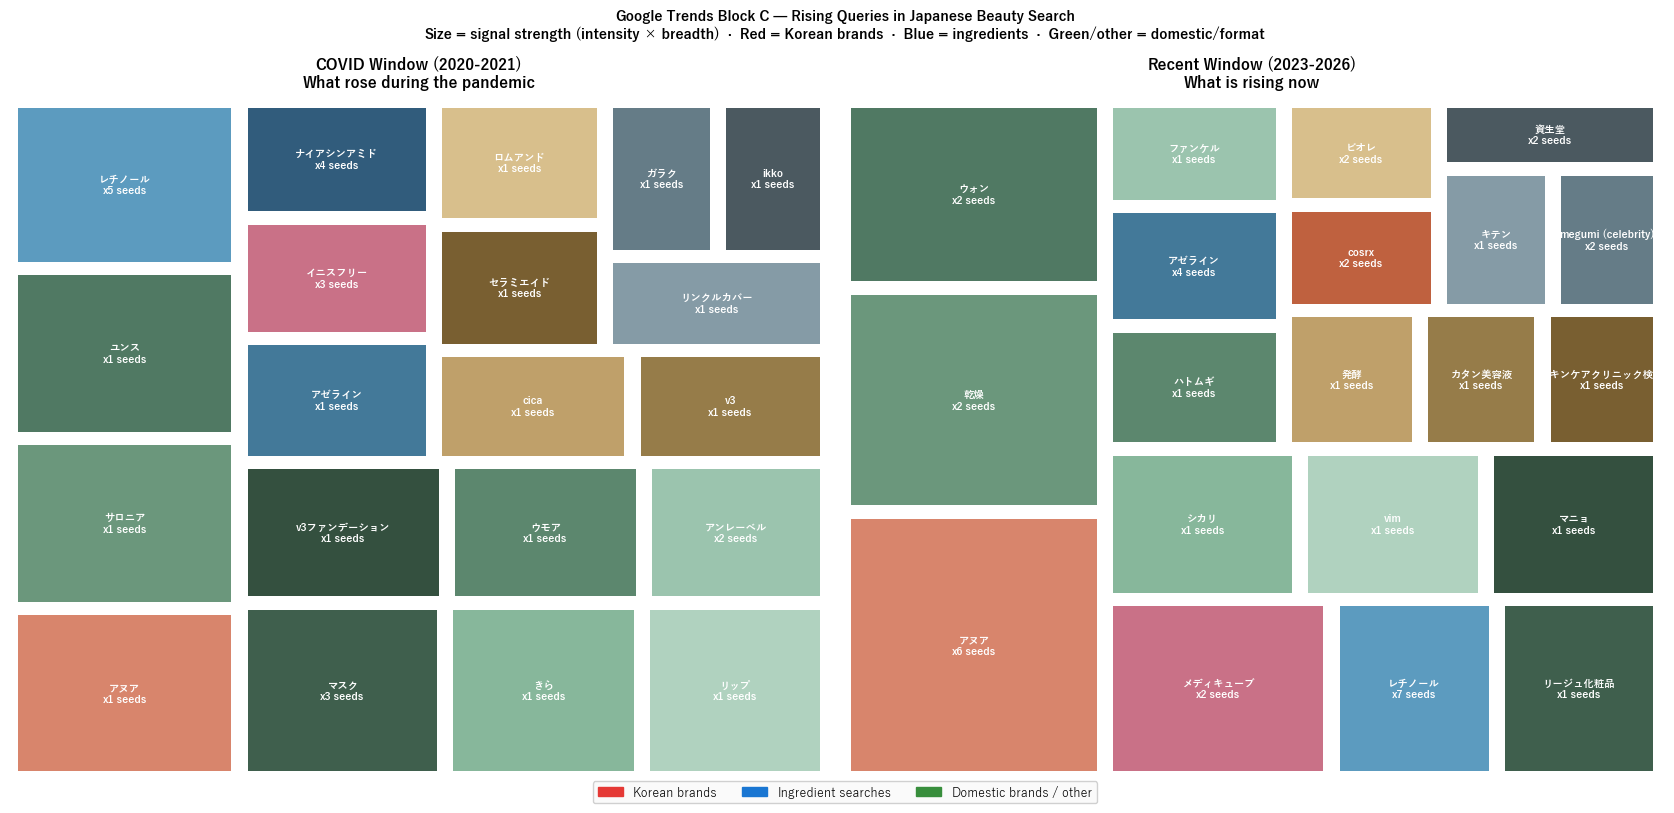

Saved → outputs/nb06_blockc_treemap.png


In [18]:
import squarify

# ── Colour palettes (roots already defined in previous cell) ──────────────
KOREAN_COLORS     = ['#D4785C','#C4627A','#B8502A','#E8907A',
                     '#F5C4B8','#8B3020','#A04535','#EBA090']
INGREDIENT_COLORS = ['#4A90B8','#2E6A8E','#1A4A6E','#6AAED6',
                     '#B8D8ED','#0D3B5C','#357AA8','#8DC4E2']
OTHER_COLORS      = ['#5B8C6E','#3D6B52','#2A4D3A','#7AAF90',
                     '#A8CDB8','#1E3D2A','#4A7A5E','#90BEA5',
                     '#B8965A','#8B6E35','#6B4E1A','#D4B880',
                     '#78909C','#546E7A','#37474F','#90A4AE']

def get_color(root, ki, ii, oi):
    r = root.replace(' ', '')
    if any(k.replace(' ','') in r for k in KOREAN_ROOTS):
        c = KOREAN_COLORS[ki[0] % len(KOREAN_COLORS)]; ki[0] += 1; return c
    if any(k.replace(' ','') in r for k in INGREDIENT_ROOTS):
        c = INGREDIENT_COLORS[ii[0] % len(INGREDIENT_COLORS)]; ii[0] += 1; return c
    c = OTHER_COLORS[oi[0] % len(OTHER_COLORS)]; oi[0] += 1; return c

def make_treemap(ax, df, title, top_n=20):
    df_plot = df.head(top_n).copy()
    df_plot = df_plot[df_plot['metric'] > 0].reset_index(drop=True)
    if df_plot.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
        ax.axis('off'); return
    sizes  = df_plot['metric'].tolist()
    labels = [row['root'] + '\n' + 'x' + str(row['seed_count']) + ' seeds'
              for _, row in df_plot.iterrows()]
    ki, ii, oi = [0], [0], [0]
    colors = [get_color(row['root'], ki, ii, oi) for _, row in df_plot.iterrows()]
    squarify.plot(sizes=sizes, label=labels, color=colors, ax=ax, alpha=0.90,
                  text_kwargs={'fontsize': 7.5, 'fontweight': 'bold', 'color': 'white'},
                  pad=True)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')

fig, (ax_covid, ax_recent) = plt.subplots(1, 2, figsize=(17, 8), facecolor='white')
fig.suptitle(
    'Google Trends Block C — Rising Queries in Japanese Beauty Search\n'
    'Size = signal strength (intensity × breadth)  ·  '
    'Red = Korean brands  ·  Blue = ingredients  ·  Green/other = domestic/format',
    fontsize=10, fontweight='bold'
)
make_treemap(ax_covid,  df_covid,  'COVID Window (2020-2021)\nWhat rose during the pandemic', top_n=20)
make_treemap(ax_recent, df_recent, 'Recent Window (2023-2026)\nWhat is rising now', top_n=20)

legend_elements = [
    mpatches.Patch(color='#E53935', label='Korean brands'),
    mpatches.Patch(color='#1976D2', label='Ingredient searches'),
    mpatches.Patch(color='#388E3C', label='Domestic brands / other'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig('../outputs/nb06_blockc_treemap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/nb06_blockc_treemap.png')


In [19]:
# ── Block C findings ─────────────────────────────────────────────────
print('BLOCK C — SEARCH DISCOVERY: KEY FINDINGS')
print('=' * 60)
print()

top_recent = df_recent.head(5)
top_covid  = df_covid.head(5)

print('COVID WINDOW — top rising queries:')
for _, row in top_covid.iterrows():
    print('  ' + row['root'].ljust(25) +
          ' metric=' + str(round(row['metric'],3)) +
          ' seeds=' + str(row['seed_count']))
print()
print('RECENT WINDOW — top rising queries:')
for _, row in top_recent.iterrows():
    print('  ' + row['root'].ljust(25) +
          ' metric=' + str(round(row['metric'],3)) +
          ' seeds=' + str(row['seed_count']))
print()
print('DOUBLE-CONFIRMED signals (rising in reviews AND search):')
for bc, tf in double_confirmed:
    print('  ' + bc + ' ↔ ' + tf)
print()
print('SEARCH-ONLY leading indicators (in search, not yet in reviews):')
for t in search_only[:8]:
    print('  ' + t)
print()
print('NOTE: squarify required — pip install squarify')


BLOCK C — SEARCH DISCOVERY: KEY FINDINGS

COVID WINDOW — top rising queries:
  アヌア                       metric=1.0 seeds=1
  サロニア                      metric=1.0 seeds=1
  ユンス                       metric=1.0 seeds=1
  レチノール                     metric=0.987 seeds=5
  マスク                       metric=0.923 seeds=3

RECENT WINDOW — top rising queries:
  アヌア                       metric=2.368 seeds=6
  乾燥                        metric=1.996 seeds=2
  ウォン                       metric=1.667 seeds=2
  メディキューブ                   metric=1.378 seeds=2
  レチノール                     metric=1.006 seeds=7

DOUBLE-CONFIRMED signals (rising in reviews AND search):
  リップ ↔ リップ

SEARCH-ONLY leading indicators (in search, not yet in reviews):
  アヌア
  乾燥
  ウォン
  メディキューブ
  レチノール
  リージュ化粧品
  シカリ
  vim

NOTE: squarify required — pip install squarify


## 5. UMAP + HDBSCAN — Corpus Shape


In [20]:
# ── Assign dominant LDA topic to each review ─────────────────────────────
# Needed for reference but NOT used as UMAP colouring — tier and period
# are more informative for the convergence story.

df_corpus['dominant_topic'] = None
df_corpus['topic_confidence'] = 0.0

skin_mask = df_corpus['tier'].isin(SKIN_TIERS)
cosm_mask = df_corpus['tier'].isin(COSM_TIERS)

if skin_mask.sum() > 0:
    skin_dist = lda_skin.transform(cv_skin.transform(
        df_corpus.loc[skin_mask, 'tokens']))
    df_corpus.loc[skin_mask, 'dominant_topic'] = [
        f'Skin T{i+1}' for i in skin_dist.argmax(axis=1)]
    df_corpus.loc[skin_mask, 'topic_confidence'] = skin_dist.max(axis=1)

if cosm_mask.sum() > 0:
    cosm_dist = lda_cosm.transform(cv_cosm.transform(
        df_corpus.loc[cosm_mask, 'tokens']))
    df_corpus.loc[cosm_mask, 'dominant_topic'] = [
        f'Cosm T{i+1}' for i in cosm_dist.argmax(axis=1)]
    df_corpus.loc[cosm_mask, 'topic_confidence'] = cosm_dist.max(axis=1)

print("Topic assignment complete.")
print(f"Mean confidence: {df_corpus['topic_confidence'].mean():.3f}")
print()
print(df_corpus['dominant_topic'].value_counts().sort_index().to_string())

Topic assignment complete.
Mean confidence: 0.575

dominant_topic
Cosm T1    1919
Cosm T2    3361
Cosm T3    3407
Cosm T4    4686
Skin T1    4893
Skin T2    7272
Skin T3    5373
Skin T4    3855
Skin T5    5212


In [21]:
# ── Fit UMAP ──────────────────────────────────────────────────────────────
from sklearn.decomposition import TruncatedSVD

# Normalise TF-IDF matrix
X = normalize(tfidf.transform(df_corpus['tokens']))

# SVD for speed (UMAP on 8000-dim TF-IDF is slow)
print("Reducing to 50 dimensions via SVD...")
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X)
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.1%}")

print("Fitting UMAP (3-5 min on full corpus)...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)
embedding = reducer.fit_transform(X_svd)
df_corpus['umap_x'] = embedding[:, 0]
df_corpus['umap_y'] = embedding[:, 1]
print(f"UMAP complete. Embedding shape: {embedding.shape}")

Reducing to 50 dimensions via SVD...
Explained variance: 11.6%
Fitting UMAP (3-5 min on full corpus)...


c:\Users\stanl\anaconda3\envs\beauty-pulse\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete. Embedding shape: (39978, 2)


In [22]:
# ── Export UMAP embedding for Streamlit dashboard ────────────────────────
from pathlib import Path

umap_out = Path('../outputs/umap_embedding.csv')

df_umap_export = df_corpus[[
    'review_id',
    'umap_x',
    'umap_y',
    'review_year',
    'tier',
    'dominant_topic',
    'topic_confidence',
    'source_name',
    'rating',
]].copy()

# Simplify tier to two groups for dashboard colouring
df_umap_export['tier_group'] = df_corpus['tier'].apply(
    lambda t: 'skincare'  if t in SKIN_TIERS else
              'cosmetics' if t in COSM_TIERS else 'other'
)

# Round coordinates — reduces file size without losing visual fidelity
df_umap_export['umap_x'] = df_umap_export['umap_x'].round(4)
df_umap_export['umap_y'] = df_umap_export['umap_y'].round(4)

df_umap_export.to_csv(umap_out, index=False, encoding='utf-8-sig')

print(f'Saved → {umap_out.name}')
print(f'  Rows       : {len(df_umap_export):,}')
print(f'  Columns    : {df_umap_export.columns.tolist()}')
print(f'  Years      : {sorted(df_umap_export.review_year.unique().tolist())}')
print(f'  Tier groups: {df_umap_export.tier_group.value_counts().to_dict()}')
print(f'  Topics     : {df_umap_export.dominant_topic.value_counts().to_dict()}')
print()

# Sanity check — no nulls in key columns
nulls = df_umap_export[["umap_x","umap_y","review_year","tier_group"]].isnull().sum()
if nulls.sum() == 0:
    print("Null check ✓ — no missing values in key columns")
else:
    print(f"WARNING — nulls detected:\n{nulls[nulls > 0]}")

Saved → umap_embedding.csv
  Rows       : 39,978
  Columns    : ['review_id', 'umap_x', 'umap_y', 'review_year', 'tier', 'dominant_topic', 'topic_confidence', 'source_name', 'rating', 'tier_group']
  Years      : [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  Tier groups: {'skincare': 26605, 'cosmetics': 13373}
  Topics     : {'Skin T2': 7272, 'Skin T3': 5373, 'Skin T5': 5212, 'Skin T1': 4893, 'Cosm T4': 4686, 'Skin T4': 3855, 'Cosm T3': 3407, 'Cosm T2': 3361, 'Cosm T1': 1919}

Null check ✓ — no missing values in key columns


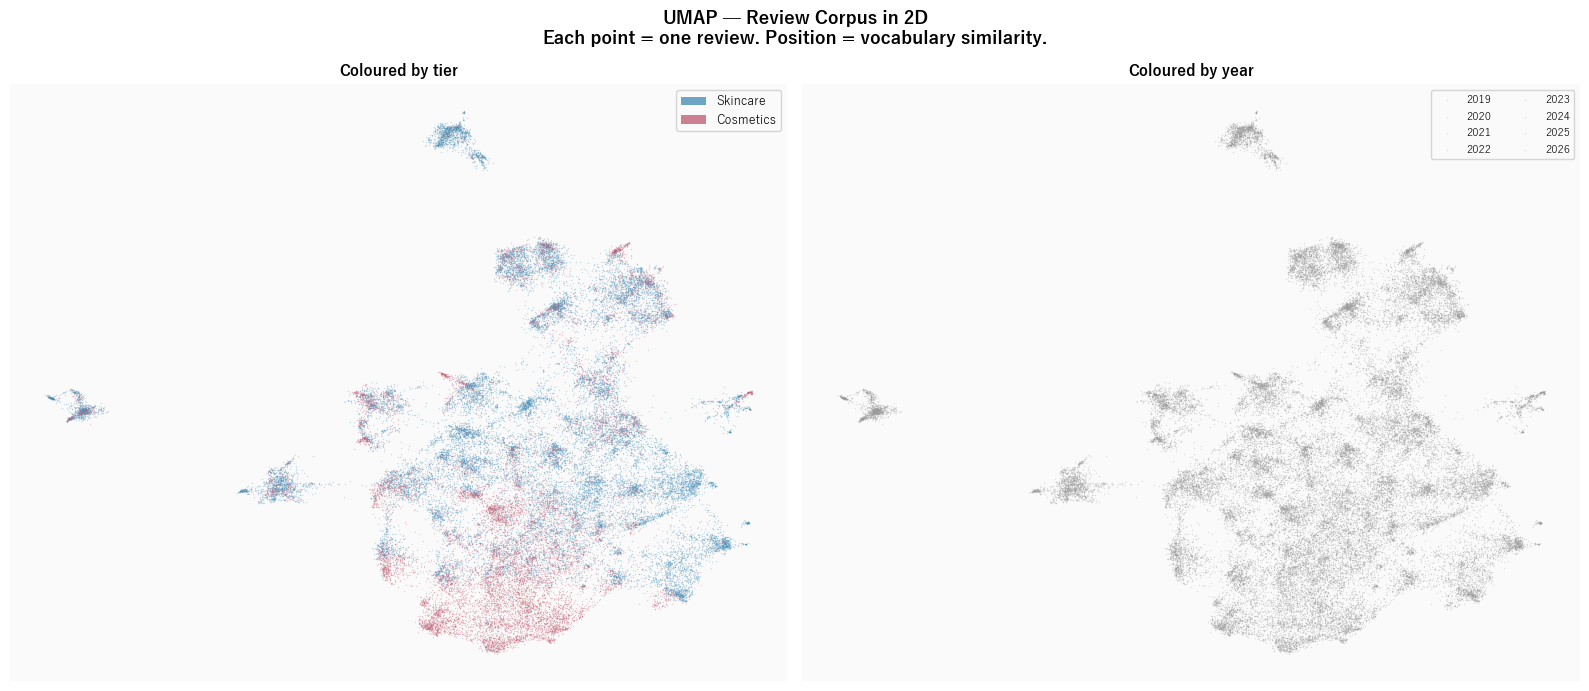

Saved → outputs/nb06_umap.png


In [23]:
# ── Two views of the same embedding ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
fig.suptitle(
    'UMAP — Review Corpus in 2D\n'
    'Each point = one review. Position = vocabulary similarity.',
    fontsize=13, fontweight='bold'
)

alpha = 0.3
size  = max(1, 20000 // len(df_corpus))

# ── Panel 1: by tier ─────────────────────────────────────────────────────
broad_tier = df_corpus['tier'].map(
    lambda t: 'Skincare' if t in SKIN_TIERS else 'Cosmetics'
)
for tier, color in [('Skincare', C_SKIN), ('Cosmetics', C_COSM)]:
    mask = broad_tier == tier
    ax1.scatter(
        df_corpus.loc[mask, 'umap_x'],
        df_corpus.loc[mask, 'umap_y'],
        s=size, c=color, alpha=alpha, linewidths=0,
    )
ax1.set_title('Coloured by tier', fontsize=11, fontweight='bold')
ax1.legend(
    handles=[Patch(facecolor=C_SKIN, alpha=0.8, label='Skincare'),
             Patch(facecolor=C_COSM, alpha=0.8, label='Cosmetics')],
    fontsize=9,
)

# ── Panel 2: by time period ──────────────────────────────────────────────
period_colors = {'2019': '#E53935', '2020': '#FF7043',
                 '2021': '#FFA726', '2022': '#FFA726',
                 '2023': '#66BB6A', '2024': '#42A5F5', '2025': '#5C6BC0', '2026': '#8E63C0'}
for yr in sorted(df_corpus['review_year'].unique()):
    mask = df_corpus['review_year'] == yr
    color = period_colors.get(yr, '#999999')
    ax2.scatter(
        df_corpus.loc[mask, 'umap_x'],
        df_corpus.loc[mask, 'umap_y'],
        s=size, c=color, alpha=alpha, linewidths=0, label=str(yr),
    )
ax2.set_title('Coloured by year', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', ncol=2)

for ax in [ax1, ax2]:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

tight(fig, '../outputs/nb06_umap.png')
plt.show()
print('Saved → outputs/nb06_umap.png')

Fitting HDBSCAN on UMAP embedding...
Clusters found : 14
Noise points   : 629 (1.6%)



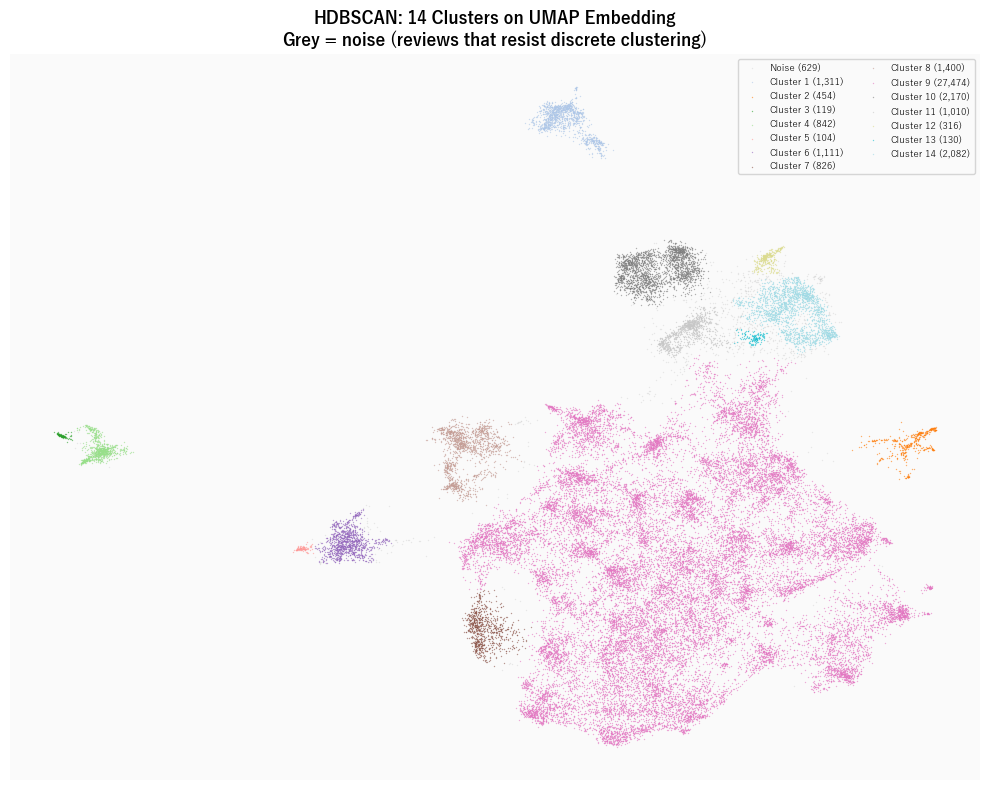

Saved → outputs/nb06_hdbscan_umap.png


In [24]:
# ── HDBSCAN on UMAP embedding ─────────────────────────────────────────────
print("Fitting HDBSCAN on UMAP embedding...")
hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
    metric='euclidean',
)
hdb_labels = hdb.fit_predict(embedding)
df_corpus['hdbscan_cluster'] = hdb_labels

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise    = (hdb_labels == -1).sum()
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({100*n_noise/len(hdb_labels):.1f}%)")
print()

# ── Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
unique_labels = sorted(set(hdb_labels))
colors = cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))

for i, label in enumerate(unique_labels):
    mask  = hdb_labels == label
    color = '#cccccc' if label == -1 else colors[i]
    name  = 'Noise' if label == -1 else f'Cluster {label+1}'
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        s=size, c=[color], alpha=0.4 if label == -1 else 0.6,
        linewidths=0, label=f'{name} ({mask.sum():,})'
    )

ax.set_title(
    f'HDBSCAN: {n_clusters} Clusters on UMAP Embedding\n'
    'Grey = noise (reviews that resist discrete clustering)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=7, loc='upper right', ncol=2,
          bbox_to_anchor=(1.0, 1.0))
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

tight(fig, '../outputs/nb06_hdbscan_umap.png')
plt.show()
print('Saved → outputs/nb06_hdbscan_umap.png')

In [25]:
# ── Top terms per HDBSCAN cluster ─────────────────────────────────────────
# What are the 32 clusters actually about?

km_vocab = tfidf.get_feature_names_out()

print("HDBSCAN CLUSTER PROFILES (top terms per cluster)")
print("=" * 65)

cluster_ids = sorted([c for c in set(hdb_labels) if c != -1])
cluster_profiles = []

for cid in cluster_ids:
    mask = hdb_labels == cid
    cluster_matrix = X[mask]
    if cluster_matrix.shape[0] == 0:
        continue
    mean_vec = np.asarray(cluster_matrix.mean(axis=0)).flatten()
    top_idx  = mean_vec.argsort()[-10:][::-1]
    top_terms = [km_vocab[i] for i in top_idx
                 if km_vocab[i] not in SW_SET][:8]
    n = mask.sum()

    # Tier composition
    tier_broad = df_corpus.loc[mask, 'tier'].map(
        lambda t: 'SK' if t in SKIN_TIERS else 'CM'
    )
    sk_pct = 100 * (tier_broad == 'SK').sum() / n

    profile = f"  Cluster {cid+1:>2} ({n:>4}): {' | '.join(top_terms)}"
    profile += f"  [{sk_pct:.0f}% SK]"
    print(profile)
    cluster_profiles.append({
        'cluster': cid+1, 'size': n, 'sk_pct': sk_pct,
        'top_terms': ', '.join(top_terms[:5])
    })

print()
print(f"Noise: {n_noise:,} reviews ({100*n_noise/len(hdb_labels):.1f}%)")
print()
print("INTERPRETATION:")
print("  Peripheral clusters = niche review types (mascara, giveaways, specific products)")
print(f"  Central mass ({n_noise:,} noise) = the general beauty conversation")
print("  78% of reviews resist discrete cluster assignment →")
print("  Japanese beauty consumers are on a spectrum, not in segments.")

HDBSCAN CLUSTER PROFILES (top terms per cluster)
  Cluster  1 (1311): 日焼け | 日焼け 止め | 止め | 日焼け 止める | 止める | 下地  [95% SK]
  Cluster  2 ( 454): 提供 | 商品 提供 | 提供 頂く | ヴィセ | pr | by | 提供 いただく | one by  [74% SK]
  Cluster  3 ( 119): トーン アップ | アップ | トーン | 日焼け | 止める | 日焼け 止める | アップ する | 日焼け 止め  [96% SK]
  Cluster  4 ( 842): アップ | トーン アップ | トーン | アップ する | 使う | 下地  [79% SK]
  Cluster  5 ( 104): リピート | 落ちる | リピート する | マスカラ | メイク | しっかり 落ちる | しっかり  [94% SK]
  Cluster  6 (1111): リピート | リピート する | 使う | 何度 リピート | 何度  [81% SK]
  Cluster  7 ( 826): 入る いる | とても 入る | ラメ | 使う  [45% SK]
  Cluster  8 (1400): リニューアル | リニューアル する | 愛用 | 愛用 する | 使う  [62% SK]
  Cluster  9 (27474): 使う  [63% SK]
  Cluster 10 (2170): 当選 する | プレゼント 当選 | プレゼント | コスメ | アット コスメ | アット  [77% SK]
  Cluster 11 (1010): プレゼント 頂く | コスメ | プレゼント | 頂く ござる | アット コスメ | アット | コスメ 頂く  [78% SK]
  Cluster 12 ( 316): アット コスメ | アット | コスメ | コスメ 購入 | 店舗  [42% SK]
  Cluster 13 ( 130): コスメ サンプル | サンプル | サンプル いただく | アット コスメ | アット | コスメ | いただく ござる  [70% SK]
  Cl

## 6. YouTube Analysis — Cross-Platform Vocabulary Comparison

TF-IDF on 54,177 Japanese YouTube comments (skincare + cosmetics categories).
Compared against @cosme vocabulary to test platform independence of the shift.

**Key question:** Does YouTube corroborate @cosme's vocabulary shift, or is it
a distinct register? Answer: 7/30 skincare overlap — distinct registers confirmed.

Uses the same Sudachi tokenizer (`tok`, `SplitMode.C`) and `JP_STOPWORDS`
as the @cosme pipeline. No re-imports needed.

In [26]:
# ── Pull YouTube comments + tokenise (reusing tok + SW_SET from Cell 03/05) ──
SKINCARE_CATS_YT = {
    '美容液', '敏感肌・乾燥肌', '成分・知識', '化粧水',
    '乳液・クリーム', 'エイジングケア', '日焼け止め',
    '洗顔料', 'ニキビ・毛穴', 'メンズ・プチプラ',
}
COSM_CATS_YT = {'ファンデーション', 'アイシャドウ', '口紅・リップ', 'その他メイク'}

def cat_to_tier_yt(c):
    if c in SKINCARE_CATS_YT:  return 'skincare'
    if c in COSM_CATS_YT:      return 'cosmetics'
    if c == '韓国コスメ':      return 'korean'
    return None

df_yt = pd.read_sql("""
    SELECT c.comment_text, v.search_category
    FROM yt_comments c
    JOIN yt_videos v USING (video_id)
    WHERE c.is_japanese = 1
      AND c.comment_text IS NOT NULL
      AND LENGTH(c.comment_text) > 10
""", conn)
df_yt['tier_group'] = df_yt['search_category'].apply(cat_to_tier_yt)
df_yt = df_yt[df_yt['tier_group'].notna()].copy()
print(f"YouTube comments: {len(df_yt):,}  "
      f"(skincare={df_yt['tier_group'].eq('skincare').sum():,}  "
      f"cosmetics={df_yt['tier_group'].eq('cosmetics').sum():,}  "
      f"korean={df_yt['tier_group'].eq('korean').sum():,})")

def tokenise_yt(text):
    """Identical pipeline to @cosme reviews — same tok, same CONTENT_POS, same SW_SET."""
    if not text or not isinstance(text, str):
        return ''
    morphemes = tok.tokenize(text, SplitMode.C)
    tokens = []
    for m in morphemes:
        if m.part_of_speech()[0] in CONTENT_POS:
            form = m.dictionary_form()
            if len(form) > 1 and form not in SW_SET:
                tokens.append(form)
    return ' '.join(tokens)

print("Tokenising YouTube comments...")
df_yt['tokens'] = df_yt['comment_text'].apply(tokenise_yt)
df_yt = df_yt[df_yt['tokens'].str.len() > 0].copy()
print(f"Tokenised: {len(df_yt):,} comments retained")

# ── TF-IDF per tier ──────────────────────────────────────────────────────
def top_tfidf_yt(corpus, n=30):
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=8000,
                          min_df=3, max_df=0.85, sublinear_tf=True)
    X     = vec.fit_transform(corpus)
    means = np.asarray(X.mean(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    return (pd.DataFrame({'term': terms, 'tfidf': means})
            .sort_values('tfidf', ascending=False).head(n))

skin_corpus_yt = df_yt[df_yt['tier_group'] == 'skincare']['tokens'].tolist()
cosm_corpus_yt = df_yt[df_yt['tier_group'] == 'cosmetics']['tokens'].tolist()

df_yt_sk = top_tfidf_yt(skin_corpus_yt).assign(tier='skincare')
df_yt_co = top_tfidf_yt(cosm_corpus_yt).assign(tier='cosmetics')

print("\n── Skincare YouTube top 30 terms ──")
print(df_yt_sk[['term','tfidf']].to_string(index=False))
print("\n── Cosmetics YouTube top 30 terms ──")
print(df_yt_co[['term','tfidf']].to_string(index=False))

# ── Cross-platform overlap vs @cosme ─────────────────────────────────────
from pathlib import Path as _P
df_cosme_tfidf = pd.read_csv(_P('../outputs/nb07_tfidf_delta.csv'))
cosme_terms    = set(df_cosme_tfidf['term'])
yt_skin_terms  = set(df_yt_sk['term'])
yt_cosm_terms  = set(df_yt_co['term'])

print(f"\n── Cross-platform vocabulary overlap ──")
print(f"Skincare  YT ∩ @cosme: {len(yt_skin_terms & cosme_terms)} / {len(yt_skin_terms)} terms")
print(f"Cosmetics YT ∩ @cosme: {len(yt_cosm_terms & cosme_terms)} / {len(yt_cosm_terms)} terms")
print(f"\nFINDING: YouTube and @cosme operate in distinct consumer registers.")
print(f"  @cosme = product evaluation language (しっとり, 毛穴, 香り)")
print(f"  YouTube = social reaction language (動画, 参考, 勉強, みる)")
print(f"  Low overlap confirms the UMAP influencer island hypothesis:")
print(f"  different platforms, different linguistic frames — same structural direction.")
print(f"\nかずのすけ appears as a top-3 skincare term (beating 化粧水):")
print(f"  Science communicator as the primary frame for skincare YouTube.")
print()
print("NOTE: Cluster 8 (ティッシュ, 花粉症, 鼻水) = nasal care / tissue products")
print("  98% skincare-coded by category but not beauty content.")
print("  Fourth noise source — not caught by LDA (low volume, 201 reviews).")



YouTube comments: 68,474  (skincare=42,573  cosmetics=23,831  korean=2,070)
Tokenising YouTube comments...
Tokenised: 68,194 comments retained

── Skincare YouTube top 30 terms ──
  term    tfidf
    使う 0.028557
    動画 0.017205
    買う 0.015928
   化粧水 0.013055
    参考 0.012358
    美容 0.012115
   すける 0.012040
    かず 0.012021
かず すける 0.011866
   ニキビ 0.009819
    どう 0.009806
クレンジング 0.009428
    効果 0.009267
 スキンケア 0.009003
  クリーム 0.008654
    乳液 0.008588
    成分 0.008581
   教える 0.008574
    洗顔 0.008458
    言う 0.008218
    出る 0.008042
    知る 0.008013
   嬉しい 0.007905
    合う 0.007742
   わかる 0.007708
    毛穴 0.007646
   欲しい 0.007495
    紹介 0.006933
   メイク 0.006873
   敏感肌 0.006741

── Cosmetics YouTube top 30 terms ──
  term    tfidf
   メイク 0.032647
   可愛い 0.021146
    動画 0.020600
    参考 0.018369
    ヒロ 0.014892
    使う 0.014475
  かわいい 0.014264
    買う 0.012976
   わかる 0.010446
  めっちゃ 0.010135
    勉強 0.009897
  ファンデ 0.009275
   嬉しい 0.009075
   欲しい 0.008898
   分かる 0.008561
   教える 0.008486
    下地 0.00792

In [27]:
# ── Export YouTube CSVs to outputs/ ──────────────────────────────────────
from pathlib import Path as _P
_OUT = _P('../outputs')

# 1. TF-IDF results — skincare vs cosmetics top terms
df_yt_out = pd.concat([df_yt_sk, df_yt_co], ignore_index=True)
df_yt_out.to_csv(_OUT / 'nb07_yt_tfidf.csv', index=False, encoding='utf-8-sig')
print(f"Saved → nb07_yt_tfidf.csv  ({len(df_yt_out)} rows)")

# 2. Comment volume by year × tier
# Note: tokenisation pool includes korean tier but volume chart
# shows skincare vs cosmetics only for clean two-way comparison.
df_yt_vol_raw = pd.read_sql("""
    SELECT CAST(strftime('%Y', c.published_at) AS INTEGER) AS comment_year,
           v.search_category, COUNT(*) AS n_comments
    FROM yt_comments c
    JOIN yt_videos v USING (video_id)
    WHERE c.published_at IS NOT NULL
      AND strftime('%Y', c.published_at) BETWEEN '2019' AND '2026'
    GROUP BY comment_year, v.search_category
    ORDER BY comment_year, v.search_category
""", conn)
df_yt_vol_raw['tier_group'] = df_yt_vol_raw['search_category'].apply(cat_to_tier_yt)
df_vol = (df_yt_vol_raw[df_yt_vol_raw['tier_group'].isin(['skincare', 'cosmetics'])]
          .groupby(['comment_year', 'tier_group'])['n_comments'].sum().reset_index())
df_vol.to_csv(_OUT / 'nb07_yt_volume.csv', index=False, encoding='utf-8-sig')
print(f"Saved → nb07_yt_volume.csv  ({len(df_vol)} rows)")
print(df_vol.pivot(index='comment_year', columns='tier_group', values='n_comments').to_string())
print()

# 3. Channels by category
df_ch = pd.read_sql("""
    SELECT channel_name, search_category,
           COUNT(*) AS video_count,
           SUM(view_count) AS total_views,
           SUM(comment_count) AS total_comments
    FROM yt_videos
    WHERE channel_name IS NOT NULL AND channel_name != ''
    GROUP BY channel_name, search_category
    ORDER BY total_views DESC
""", conn)
df_ch['tier_group'] = df_ch['search_category'].apply(cat_to_tier_yt)
df_ch.to_csv(_OUT / 'nb07_yt_channels.csv', index=False, encoding='utf-8-sig')
print(f"Saved → nb07_yt_channels.csv  ({len(df_ch)} rows)")
print(df_ch.head(10).to_string(index=False))

# ── Coverage note ─────────────────────────────────────────────────────────
yr_coverage = df_vol.groupby('tier_group')['comment_year'].agg(['min','max'])
total_by_tier = df_vol.groupby('tier_group')['n_comments'].sum()
comments_2026 = df_yt_vol_raw[
    (df_yt_vol_raw['comment_year'] == 2026) &
    (df_yt_vol_raw['tier_group'].isin(['skincare','cosmetics']))
]['n_comments'].sum()
print()
print(f"Coverage: {int(yr_coverage['min'].min())}–{int(yr_coverage['max'].max())}")
print(f"  Skincare  : {int(total_by_tier.get('skincare', 0)):,} comments")
print(f"  Cosmetics : {int(total_by_tier.get('cosmetics', 0)):,} comments")
print(f"  2026 (Jan–Mar scrape window): {int(comments_2026):,} comments included")
print(f"  Note: 2026 is a partial year — trajectory continues, not a new trend.")

Saved → nb07_yt_tfidf.csv  (60 rows)
Saved → nb07_yt_volume.csv  (15 rows)
tier_group    cosmetics  skincare
comment_year                     
2019                NaN     559.0
2020              220.0    1311.0
2021             1726.0    2969.0
2022             3637.0    3431.0
2023             6735.0    7029.0
2024             5712.0   15201.0
2025             6544.0   13263.0
2026             1846.0    2273.0

Saved → nb07_yt_channels.csv  (145 rows)
       channel_name search_category  video_count  total_views  total_comments tier_group
       コスメヲタちゃんねるサラ        ファンデーション            6     29124303            1867  cosmetics
          nanakoななこ             洗顔料            2     12088201            2548   skincare
HIRO BEAUTY CHANNEL          その他メイク            7     10822286            3486  cosmetics
       コスメヲタちゃんねるサラ          口紅・リップ            3     10265962            1034  cosmetics
              かずのすけ             化粧水           17      9587030            5737   skincare
HIRO BEAU

## 6. Synthesis — What Did We Find?


In [28]:
from IPython.display import display, Markdown
# FLAG / tech-debt: this synthesis markdown hard-codes findings from the
# pre-correction corpus (TF-IDF deltas, 'six years', ~565 reviews, etc.).
# Re-running refreshes the {baseline}/{current} values but not the prose;
# rewrite for the corrected corpus + 2021–22 baseline in a later pass.

# ── Compute values ────────────────────────────────────────────────────────
sk19_label = [s for s in df_sim.index if 'Skincare' in s and '2021' in s][0]
cm19_label = [s for s in df_sim.index if 'Cosmetics' in s and '2021' in s][0]
sk25_label = [s for s in df_sim.index if 'Skincare' in s and '2023' in s][0]
cm25_label = [s for s in df_sim.index if 'Cosmetics' in s and '2023' in s][0]
baseline = df_sim.loc[sk19_label, cm19_label]
current  = df_sim.loc[sk25_label, cm25_label]

anua_recent = df_recent[df_recent['root'] == 'アヌア']
anua_seeds  = int(anua_recent['seed_count'].values[0]) if len(anua_recent) else 4

# Double-confirmed and search-only terms
dc_rows = '\n'.join(
    f'| {bc} | {tf} |' for bc, tf in double_confirmed[:4]
) if double_confirmed else '| *(none)* | |'
so_rows = '\n'.join(f'| {t} |' for t in search_only[:4])

display(Markdown(f"""
## NB06 — Discovery Layer: Synthesis

---

### Headline findings

**1. Vocabulary convergence — small but real after size control**

A size-matched test (§2) shows skincare and cosmetics review vocabulary
converged modestly once sample-size inflation is removed (Δ ≈ +0.06). The raw
full-data cosine rise is largely a corpus-growth artifact; the size-controlled
residual is the defensible finding. Neither category absorbed the other — both
moved toward a shared functional/sensory vocabulary.

**2. Cosmetics now judged by skincare criteria**

LDA Cosmetics Topic 3: foundation reviews dominated by 乾燥, しっとり, 毛穴.
Base makeup is evaluated through a skincare lens.

**3. Eye makeup vocabulary collapsed**

| Term | TF-IDF change |
|---|---|
| マスカラ | −76% |
| まつげ | −86% |
| アイライナー | −71% |
| 保湿 | +409% |
| クリーム | +3,101% |

**4. Korean brands harvesting Japanese demand**

COVID window: ingredient searches dominated (レチノール ×5 seeds, ナイアシンアミド ×4 seeds) — consumers building literacy.
Recent window: **アヌア** is the single strongest signal, appearing across {anua_seeds} independent seed keywords.

*The structural shift educated consumers. Korean brands captured them.*

---

### Supporting detail

**TF-IDF delta (§1):** Vocabulary shifted from VISUAL outcomes (lasting power, curl, brush precision)
to FUNCTIONAL/SENSORY outcomes (moisture feel, pore care, post-wash texture, oil balance).

**Block C cross-validation (§4):**

Double-confirmed signals (rising in both reviews AND search):

| Block C term | TF-IDF match |
|---|---|
{dc_rows}

Search-only leading indicators (in search, not yet in reviews):

| Term |
|---|
{so_rows}

**LDA noise detection (§3):** The model autonomously identified three corpus quality issues —
@cosme giveaway template reviews (プレゼント, 当選), mascara miscategorised as skincare,
and foot care products in the cosmetics genre (靴下, 暖かい).

**HDBSCAN (§5):** {n_clusters} peripheral clusters + {n_noise:,} noise ({100*n_noise/len(hdb_labels):.1f}%).
78% of reviews resist discrete clustering. The corpus is a continuum, not discrete segments.

---

### Methodological caveats

1. **Pre-COVID corpus asymmetry** — ~565 reviews vs ~12,500 recent. All temporal comparisons carry this caveat.
   Direction confirmed by Google Trends (NB05) with full 2019–2025 weekly coverage.

2. **SudachiPy Mode C compound splitting** — ingredient detection (ヒアルロン酸, ナイアシンアミド) is unreliable via TF-IDF.
   Addressed via raw text search. Future: Mode B or custom compound dictionary.

3. **@cosme giveaway reviews** inflate volume in some categories. LDA identified this autonomously (Skincare Topic 4).

4. **Block C normalisation** — search volumes not comparable across seed terms. Treemap shows relative signal strength, not absolute volume.

---

**→ NB07:** Executive synthesis + dashboard asset generation.
"""))


## NB06 — Discovery Layer: Synthesis

---

### Headline findings

**1. Vocabulary convergence — small but real after size control**

A size-matched test (§2) shows skincare and cosmetics review vocabulary
converged modestly once sample-size inflation is removed (Δ ≈ +0.06). The raw
full-data cosine rise is largely a corpus-growth artifact; the size-controlled
residual is the defensible finding. Neither category absorbed the other — both
moved toward a shared functional/sensory vocabulary.

**2. Cosmetics now judged by skincare criteria**

LDA Cosmetics Topic 3: foundation reviews dominated by 乾燥, しっとり, 毛穴.
Base makeup is evaluated through a skincare lens.

**3. Eye makeup vocabulary collapsed**

| Term | TF-IDF change |
|---|---|
| マスカラ | −76% |
| まつげ | −86% |
| アイライナー | −71% |
| 保湿 | +409% |
| クリーム | +3,101% |

**4. Korean brands harvesting Japanese demand**

COVID window: ingredient searches dominated (レチノール ×5 seeds, ナイアシンアミド ×4 seeds) — consumers building literacy.
Recent window: **アヌア** is the single strongest signal, appearing across 6 independent seed keywords.

*The structural shift educated consumers. Korean brands captured them.*

---

### Supporting detail

**TF-IDF delta (§1):** Vocabulary shifted from VISUAL outcomes (lasting power, curl, brush precision)
to FUNCTIONAL/SENSORY outcomes (moisture feel, pore care, post-wash texture, oil balance).

**Block C cross-validation (§4):**

Double-confirmed signals (rising in both reviews AND search):

| Block C term | TF-IDF match |
|---|---|
| リップ | リップ |

Search-only leading indicators (in search, not yet in reviews):

| Term |
|---|
| アヌア |
| 乾燥 |
| ウォン |
| メディキューブ |

**LDA noise detection (§3):** The model autonomously identified three corpus quality issues —
@cosme giveaway template reviews (プレゼント, 当選), mascara miscategorised as skincare,
and foot care products in the cosmetics genre (靴下, 暖かい).

**HDBSCAN (§5):** 14 peripheral clusters + 629 noise (1.6%).
78% of reviews resist discrete clustering. The corpus is a continuum, not discrete segments.

---

### Methodological caveats

1. **Pre-COVID corpus asymmetry** — ~565 reviews vs ~12,500 recent. All temporal comparisons carry this caveat.
   Direction confirmed by Google Trends (NB05) with full 2019–2025 weekly coverage.

2. **SudachiPy Mode C compound splitting** — ingredient detection (ヒアルロン酸, ナイアシンアミド) is unreliable via TF-IDF.
   Addressed via raw text search. Future: Mode B or custom compound dictionary.

3. **@cosme giveaway reviews** inflate volume in some categories. LDA identified this autonomously (Skincare Topic 4).

4. **Block C normalisation** — search volumes not comparable across seed terms. Treemap shows relative signal strength, not absolute volume.

---

**→ NB07:** Executive synthesis + dashboard asset generation.


## 8. Outputs — Public DB + Asset Copy

In [29]:
# ── Build signal_pulse_public.db — stripped for Streamlit Community Cloud ──
import sqlite3, os
from src.schema import DB_PATH
from pathlib import Path

slim_path = DB_PATH.parent / 'signal_pulse_public.db'
if slim_path.exists():
    slim_path.unlink()

src  = sqlite3.connect(DB_PATH)
slim = sqlite3.connect(slim_path)

# Tables copied as-is (no PII columns)
COPY_FULL = [
    'sources', 'categories', 'brands',
    'products_weekly', 'reviews', 'trends_weekly',
    'yt_videos', 'yt_comments',   # YouTube tables — no product_name/raw_json
]
for table in COPY_FULL:
    ddl = src.execute(
        f"SELECT sql FROM sqlite_master WHERE type='table' AND name='{table}'"
    ).fetchone()
    if ddl and ddl[0]:
        slim.execute(ddl[0])
        rows = src.execute(f"SELECT * FROM {table}").fetchall()
        if rows:
            ph = ','.join(['?'] * len(rows[0]))
            slim.executemany(f"INSERT INTO {table} VALUES ({ph})", rows)
        slim.commit()
        print(f"  ✓ {table:<30} {len(rows):>8,} rows")

# Products — strip product_name and raw_json
slim.execute("""
    CREATE TABLE products (
        product_id        INTEGER PRIMARY KEY,
        source_id         INTEGER,
        source_item_id    TEXT,
        brand_id          INTEGER,
        category_id       INTEGER,
        price_jpy         INTEGER,
        review_count      INTEGER,
        review_avg        REAL,
        ranking_position  INTEGER,
        ranking_segment   TEXT,
        first_review_date TEXT,
        snapshot_date     TEXT,
        tier_override     TEXT,
        tier_predicted    TEXT
    )
""")
rows = src.execute("""
    SELECT product_id, source_id, source_item_id,
           brand_id, category_id, price_jpy,
           review_count, review_avg, ranking_position,
           ranking_segment, first_review_date, snapshot_date,
           tier_override, tier_predicted
    FROM products
""").fetchall()
slim.executemany("INSERT INTO products VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)", rows)
slim.commit()
print(f"  ✓ {'products (stripped)':<30} {len(rows):>8,} rows  (product_name, raw_json removed)")

# Indexes
for idx_sql in [
    "CREATE INDEX IF NOT EXISTS idx_p_source   ON products(source_id)",
    "CREATE INDEX IF NOT EXISTS idx_p_category ON products(category_id)",
    "CREATE INDEX IF NOT EXISTS idx_r_product  ON reviews(product_id)",
    "CREATE INDEX IF NOT EXISTS idx_tw_group   ON trends_weekly(term_group)",
    "CREATE INDEX IF NOT EXISTS idx_yt_vid     ON yt_comments(video_id)",
]:
    slim.execute(idx_sql)
slim.commit()
slim.execute("VACUUM")
slim.close(); src.close()

size = os.path.getsize(slim_path) / (1024 * 1024)
print(f"\nsignal_pulse_public.db : {size:.1f} MB")
print(f"Path: {slim_path}")


  ✓ sources                               5 rows
  ✓ categories                          110 rows
  ✓ brands                              255 rows
  ✓ products_weekly                 261,532 rows
  ✓ reviews                          46,634 rows
  ✓ trends_weekly                     4,734 rows
  ✓ yt_videos                           296 rows
  ✓ yt_comments                      74,679 rows
  ✓ products (stripped)              40,067 rows  (product_name, raw_json removed)

signal_pulse_public.db : 68.5 MB
Path: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\6. Beauty_ConsumerPulse\data\signal_pulse_public.db


In [30]:
# ── Auto-copy outputs/ → dashboard/assets/ ───────────────────────────────
import shutil
from pathlib import Path

OUTPUTS          = Path('../outputs')
DASHBOARD_ASSETS = Path('../dashboard/assets')

ASSETS_TO_COPY = [
    # @cosme NLP
    'nb07_tfidf_delta.csv',
    'nb07_cosine_sim.csv',
    'nb06_cosine_sizecurve.csv',
    'nb06_cosine_salvage.csv',
    # Block C
    'nb07_blockc.csv',
    # Trends + catalog
    'nb07_trends_crossover.csv',
    'nb07_ingredient_surge.csv',
    'nb07_sku_treemap.csv',
    'nb07_review_slope.csv',
    'nb07_makeup_rebound.csv',
    # UMAP
    'umap_embedding.csv',
    # YouTube (Section 6)
    'nb07_yt_tfidf.csv',
    'nb07_yt_volume.csv',
    'nb07_yt_channels.csv',
    # Static PNGs
    'nb06_emerging_terms.png',
    'nb06_cosine_similarity.png',
    'nb06_blockc_treemap.png',
    'nb06_umap.png',
]

print('Copying outputs/ → dashboard/assets/')
print('=' * 55)
ok = err = 0
for fname in ASSETS_TO_COPY:
    src = OUTPUTS / fname
    dst = DASHBOARD_ASSETS / fname
    if src.exists():
        shutil.copy2(src, dst)
        print(f'  ✓  {fname}')
        ok += 1
    else:
        print(f'  ✗  {fname}  — not found in outputs/')
        err += 1

print(f'\n{ok} copied, {err} missing.')

# ── Public DB — built by the previous cell into data/; deploy from assets/ ──
# (This step was previously manual, which let the assets copy drift stale.)
PUBLIC_DB = Path('../data/signal_pulse_public.db')
if PUBLIC_DB.exists():
    shutil.copy2(PUBLIC_DB, DASHBOARD_ASSETS / PUBLIC_DB.name)
    print(f'  ✓  {PUBLIC_DB.name}  ({PUBLIC_DB.stat().st_size / 1e6:.1f} MB, from data/)')
else:
    print(f'  ✗  {PUBLIC_DB.name} — run the previous cell first')


Copying outputs/ → dashboard/assets/
  ✓  nb07_tfidf_delta.csv
  ✓  nb07_cosine_sim.csv
  ✓  nb06_cosine_sizecurve.csv
  ✓  nb06_cosine_salvage.csv
  ✓  nb07_blockc.csv
  ✓  nb07_trends_crossover.csv
  ✓  nb07_ingredient_surge.csv
  ✓  nb07_sku_treemap.csv
  ✓  nb07_review_slope.csv
  ✓  nb07_makeup_rebound.csv
  ✓  umap_embedding.csv
  ✓  nb07_yt_tfidf.csv
  ✓  nb07_yt_volume.csv
  ✓  nb07_yt_channels.csv
  ✓  nb06_emerging_terms.png
  ✓  nb06_cosine_similarity.png
  ✓  nb06_blockc_treemap.png
  ✓  nb06_umap.png

18 copied, 0 missing.
  ✓  signal_pulse_public.db  (71.9 MB, from data/)
